In [1]:
import os
os.environ["PYTHONWARNING"] = "ignore"

In [2]:
import warnings

from numba.core.errors import NumbaDeprecationWarning

warnings.filterwarnings("ignore", category=NumbaDeprecationWarning)
warnings.filterwarnings("ignore")

In [3]:
import requests

from multiprocessing.dummy import Pool as ThreadPool

In [4]:
import pickle
import glob
import operator as op
import pandas as pd
import seaborn as sns
import numpy as np
import scanpy as sc
import loompy as lp
import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as spc

from scipy.sparse import issparse
from matplotlib.colors import LinearSegmentedColormap
from cytoolz import compose

In [5]:
# if not hasattr(np, "object"):
#     np.object = object # Fix for older libraries using np.object

In [6]:
from pyscenic.export import add_scenic_metadata
from pyscenic.utils import load_motifs
from pyscenic.transform import df2regulons
from pyscenic.rss import regulon_specificity_scores
from pyscenic.plotting import plot_rss

In [7]:
sc.settings.set_figure_params(frameon=False, vector_friendly=True)
sc.settings._vector_friendly = False

In [8]:
# set working directory
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# set figure directory
figure_dir = working_dir + "figures/"

# results  directory
results_dir = working_dir + "results/"

# data directory
data_dir = working_dir + "data/"

# auxiliary directory
auxiliary_dir = working_dir + "auxiliaries/"

# resource directory
resource_dir = working_dir + "resources/"

# create directories if they do not exist
os.makedirs(figure_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)
os.makedirs(auxiliary_dir, exist_ok=True)
os.makedirs(resource_dir, exist_ok=True)

In [9]:
# # List of tuples: (local_path, url)
# urls = [
#     (
#         "auxiliaries/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather",
#         "https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/refseq_r80/mc_v10_clust/gene_based/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather",
#     ),
#     (
#         "auxiliaries/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.scores.feather",
#         "https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/refseq_r80/mc_v10_clust/gene_based/hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.scores.feather",
#     ),
#     (
#         "auxiliaries/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather",
#         "https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/refseq_r80/mc_v10_clust/gene_based/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings.feather",
#     ),
#     (
#         "auxiliaries/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.scores.feather",
#         "https://resources.aertslab.org/cistarget/databases/homo_sapiens/hg38/refseq_r80/mc_v10_clust/gene_based/hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.scores.feather",
#     ),
# ]


# def url_response(path_url_tuple):
#     path, url = path_url_tuple
#     print(f"Downloading {url} to {path} ...")
#     r = requests.get(url, stream=True)
#     r.raise_for_status()  # raise error if download fails
#     with open(path, "wb") as f:
#         for chunk in r.iter_content(chunk_size=8192):
#             if chunk:
#                 f.write(chunk)
#     print(f"Finished downloading {path}")


# # Sequential download (if preferred)
# for x in urls:
#     url_response(x)

# # Or download in parallel using thread pool (optional)
# # pool = ThreadPool(5)
# # pool.map(url_response, urls)
# # pool.close()
# # pool.join()

In [10]:
# # Motif to TF annotations:
# url = [
#     ("auxiliaries/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl",
#     "https://resources.aertslab.org/cistarget/motif2tf/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl")
# ]

# for x in url:
#     url_response(x)

# ThreadPool(2).imap_unordered(url_response, url)

In [11]:
plt.rcParams["pdf.fonttype"] = "truetype"
sc.settings.set_figure_params(frameon=False, fontsize=10)
sc.settings.verbosity = 2

In [12]:
# some helper functions
def derive_regulons(
    motifs,
    db_names=(
        "hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.rankings",
        "hg38_10kbp_up_10kbp_down_full_tx_v10_clust.genes_vs_motifs.scores",
        "hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.rankings",
        "hg38_500bp_up_100bp_down_full_tx_v10_clust.genes_vs_motifs.scores",
    ),
):
    motifs.columns = motifs.columns.droplevel(0)

    def contains(*elems):
        def f(context):
            return any(elem in context for elem in elems)

        return f

    # For the creation of regulons we only keep the 10-species databases and the activating modules. We also remove the
    # enriched motifs for the modules that were created using the method "weight>50.0%" (because these modules are not part
    # of the default settings of modules_from_adjacencies anymore.
    motifs = motifs[
        np.fromiter(
            map(compose(op.not_, contains("weight>50.0%")), motifs.Context),
            dtype=bool,
        )
        & np.fromiter(map(contains(*db_names), motifs.Context), dtype=bool)
        & np.fromiter(map(contains("activating"), motifs.Context), dtype=bool)
    ]

    # We build regulons only using enriched motifs with a NES of 3.0 or higher; we take only directly annotated TFs or TF annotated
    # for an orthologous gene into account; and we only keep regulons with at least 10 genes.
    regulons = list(
        filter(
            lambda r: len(r) >= 10,
            df2regulons(
                motifs[
                    (motifs["NES"] >= 3.0)
                    & (
                        (motifs["Annotation"] == "gene is directly annotated")
                        | (
                            motifs["Annotation"].str.startswith(
                                "gene is orthologous to"
                            )
                            & motifs["Annotation"].str.endswith(
                                "which is directly annotated for motif"
                            )
                        )
                    )
                ]
            ),
        )
    )

    # Rename regulons, i.e. remove suffix.
    return list(map(lambda r: r.rename(r.transcription_factor), regulons))


def download_file(url, destination_directory):
    # Ensure the destination directory exists
    os.makedirs(destination_directory, exist_ok=True)

    # Get the file name from the URL
    file_name = os.path.join(destination_directory, url.split("/")[-1])

    # Download the file
    response = requests.get(url)
    with open(file_name, "wb") as file:
        file.write(response.content)

    print(f"File downloaded to {file_name}")


def palplot(pal, names, colors=None, size=1):
    n = len(pal)
    f, ax = plt.subplots(1, 1, figsize=(n * size, size))
    ax.imshow(
        np.arange(n).reshape(1, n),
        cmap=mpl.colors.ListedColormap(list(pal)),
        interpolation="nearest",
        aspect="auto",
    )
    ax.set_xticks(np.arange(n) - 0.5)
    ax.set_yticks([-0.5, 0.5])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    colors = n * ["k"] if colors is None else colors
    for idx, (name, color) in enumerate(zip(names, colors)):
        ax.text(
            0.0 + idx,
            0.0,
            name,
            color=color,
            horizontalalignment="center",
            verticalalignment="center",
        )
    return f


def savepdf(fname: str, fig, folder: str = "figures") -> None:
    """
    Save figure as PDF image format.
    """
    fig.tight_layout()
    fig.savefig(os.path.join(folder, fname), format="pdf")


# Function to convert gene names
def convert_gene_name(gene_name):
    return f"Regulon({gene_name})"

In [13]:
url = "https://resources.aertslab.org/cistarget/tf_lists/allTFs_hg38.txt"
tfs_path = resource_dir + "allTFs_hg38.txt"

if not os.path.exists(tfs_path):
    download_file(url, "resources")
else:
    print(f"File {os.path.basename(tfs_path)} already exists.")

File allTFs_hg38.txt already exists.


In [14]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration_scenic.h5ad")

In [15]:
adata_full.X = adata_full.layers["counts"].copy()

## Invasive BRCA

In [16]:
adata_invasive = adata_full[adata_full.obs["type"].isin(["ER", "PR", "HER", "TNBC"])].copy()

### Transcription factors in G0 arrested cells

In [17]:
sample = "G0-arrested"

In [18]:
adata = adata_invasive[adata_invasive.obs.cycling_state_oren.isin([sample])].copy()
adata.X.max()

5683.0

In [19]:
sc.pp.filter_genes(adata, min_cells=10)

filtered out 4434 genes that are detected in less than 10 cells


In [20]:
loom_path = os.path.join(resource_dir, f"{sample}_input.loom")
loom_path_output = os.path.join(resource_dir, f"{sample}_output.loom")
loom_path_aucell = os.path.join(resource_dir, f"{sample}_aucell.loom")

In [21]:
tfs = [tf.strip() for tf in open(tfs_path)]
print(f"{np.sum(adata.var.index.isin(tfs))} / {len(tfs)} TFs are found in the object")

1613 / 1892 TFs are found in the object


In [22]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e4)
adata_log.X = np.log1p(adata_log.X)

normalizing counts per cell
    finished (0:00:00)


In [23]:
sc.pp.highly_variable_genes(adata, batch_key="type", flavor="cell_ranger", n_top_genes=2000)

extracting highly variable genes
    finished (0:00:01)


In [24]:
use_hvg = False

if use_hvg:
    mask = (adata.var["highly_variable"]) | adata.var.index.isin(tfs)
    adata = adata[:, mask]

In [25]:
# raw data to loom
row_attributes = {"Gene": np.array(adata.var.index)}
col_attributes = {
    "CellID": np.array(adata.obs.index),
    "nGene": np.array(np.sum(adata.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata.X.transpose(), axis=0)).flatten()
}
lp.create(loom_path, adata.X.transpose().toarray(), row_attributes, col_attributes)

In [26]:
num_workers = 32

outpath_adj = os.path.join(results_dir, f"{sample}_adjacencies.csv")
if not os.path.exists(outpath_adj):
    !pyscenic grn {loom_path} {tfs_path} -o $outpath_adj \
      --num_workers {num_workers} \
      --seed 0 \
      --method grnboost2

In [27]:
# see the top TF-target gene associations
adjacencies = pd.read_csv(outpath_adj, index_col=False, sep=",")
print(f"Number of associations: {adjacencies.shape[0]}")
adjacencies.head()

Number of associations: 1713565


,TF,target,importance
0,ZNF385D,CYP2A7,14.342417
1,ZNF239,AL359198.1,12.467115
2,POU2AF1,TMEM232,10.989371
3,HOXB2,ADRA2A,10.915928
4,ZNF90,MATN2,10.742712


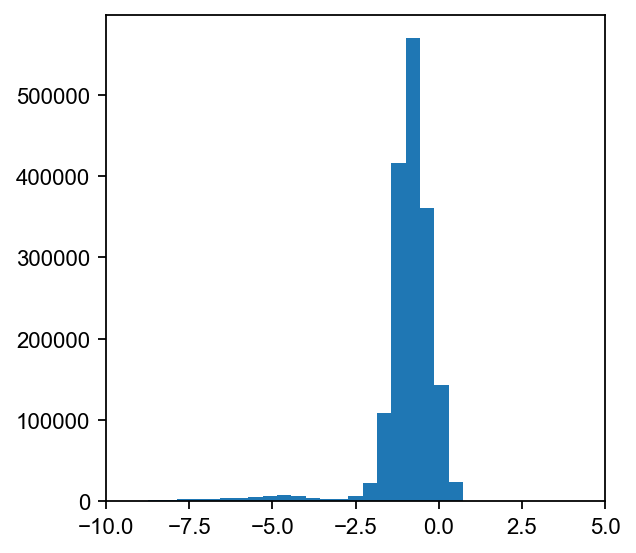

In [28]:
# visualise the distribution of weights
plt.hist(np.log10(adjacencies["importance"]), bins=50)
plt.xlim([-10, 5])
plt.grid(False)

In [29]:
# load TSS annotations
db_glob = "auxiliaries/*feather"
db_names = " ".join(glob.glob(db_glob))

In [30]:
# run the context-specific co-expression network inference
outpath_motifs = results_dir + f"/{sample}_motifs.csv"

if not os.path.exists(outpath_motifs):
    !pyscenic ctx $outpath_adj $db_names \
      --annotations_fname "auxiliaries/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl" \
      --expression_mtx_fname {loom_path} \
      --output {outpath_motifs} \
      --mask_dropouts \
      --num_workers {num_workers}

In [31]:
# Count detected genes per cell
if issparse(adata.X):
    n_genes_detected_per_cell = np.array((adata.X > 0).sum(axis=1)).ravel()
else:
    n_genes_detected_per_cell = (adata.X > 0).sum(axis=1)

# Compute percentiles
percentiles = pd.Series(n_genes_detected_per_cell).quantile([0.01, 0.05, 0.10, 0.50, 1])
print(percentiles)

0.01    1038.0
0.05    1151.0
0.10    1273.0
0.50    2168.0
1.00    6728.0
dtype: float64


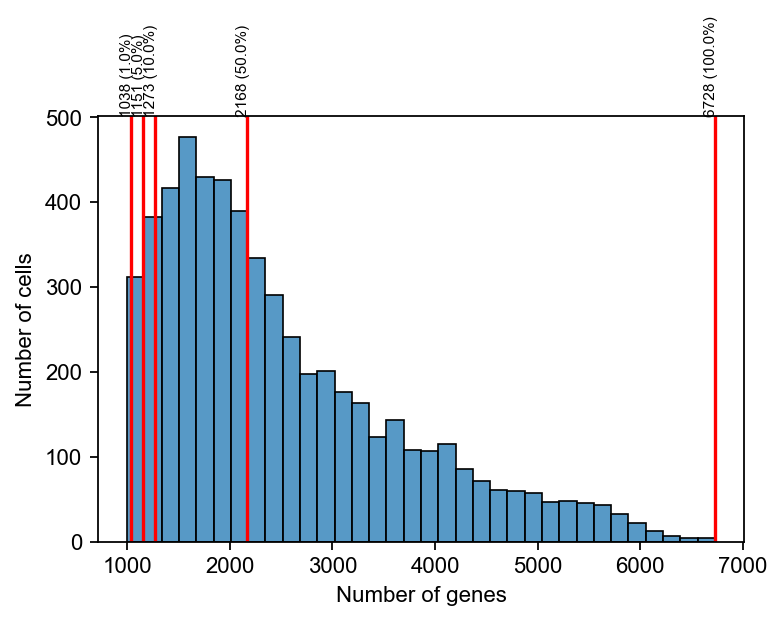

In [32]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Plot histogram
sns.histplot(
    n_genes_detected_per_cell,
    bins="fd",
    stat="count",
    kde=False,
    ax=ax,
)

# Add percentile lines and labels
for i, x in enumerate(percentiles):
    ax.axvline(x=x, color="red")
    ax.text(
        x=x,
        y=ax.get_ylim()[1],
        s=f"{int(x)} ({percentiles.index.values[i] * 100}%)",
        color="black",
        rotation=90,
        size="x-small",
        rotation_mode="anchor",
    )

# Final styling
ax.set_xlabel("Number of genes")
ax.set_ylabel("Number of cells")
fig.tight_layout()
plt.grid(False)

In [33]:
# log1p transformed data to loom for AUCell
row_attributes = {"Gene": np.array(adata_log.var.index)}
col_attributes = {
    "CellID": np.array(adata_log.obs.index),
    "nGene": np.array(np.sum(adata_log.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata_log.X.transpose(), axis=0)).flatten(),
}
aucell_path = "resources/G0_log1p_normalised.loom"
lp.create(aucell_path, adata_log.X.transpose().toarray(), row_attributes, col_attributes)

In [34]:
# monkey patch for older numpy versions

# if not hasattr(np, "msort"):
#     np.msort = np.sort  # np.sort(axis=0) behaves like msort
# if not hasattr(np, "float"):
#     np.float = float

In [35]:
motif_path = f"results/{sample}_motifs.csv"

In [36]:
if not os.path.exists(loom_path_output):
    !pyscenic aucell $aucell_path $motif_path \
      --output {loom_path_output} \
      --num_workers {num_workers} \
      --seed 0

In [37]:
lf = lp.connect(loom_path_output, mode="r+", validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [38]:
# add metadata to the adata
ad_auc_mtx = ad.AnnData(auc_mtx)
sc.pp.neighbors(ad_auc_mtx, n_neighbors=10, metric="correlation")
sc.tl.umap(ad_auc_mtx)
# add to the adata
adata.obsm["X_umap_aucell"] = ad_auc_mtx.obsm["X_umap"]

computing neighbors
computing PCA
    with n_comps=50
    finished (0:00:00)
    finished (0:00:32)
computing UMAP
    finished (0:00:08)


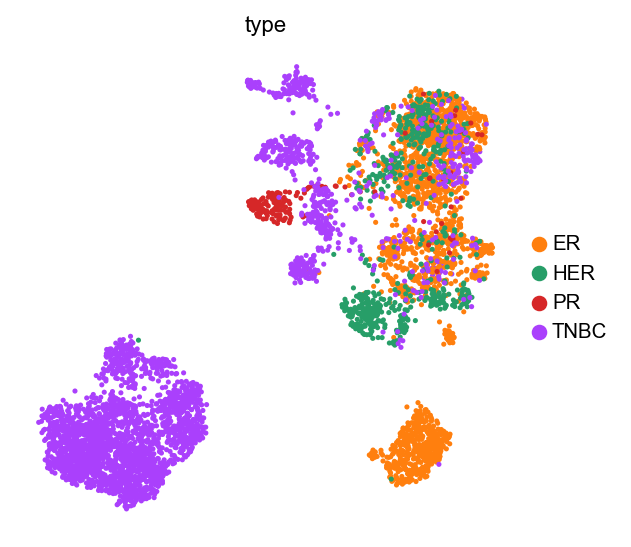

In [39]:
# visualise the new embedding space
sc.pl.embedding(adata, basis="X_umap_aucell", color="type")

In [40]:
# Create the colormap
cmap_aucell = LinearSegmentedColormap.from_list("black_to_red", ["black", "red"])
cmap_type = ["#41F6D9", "#FF95B9", "#FFD3AE", "#F782FF"]

Identified 11 modules at distance threshold 0.9


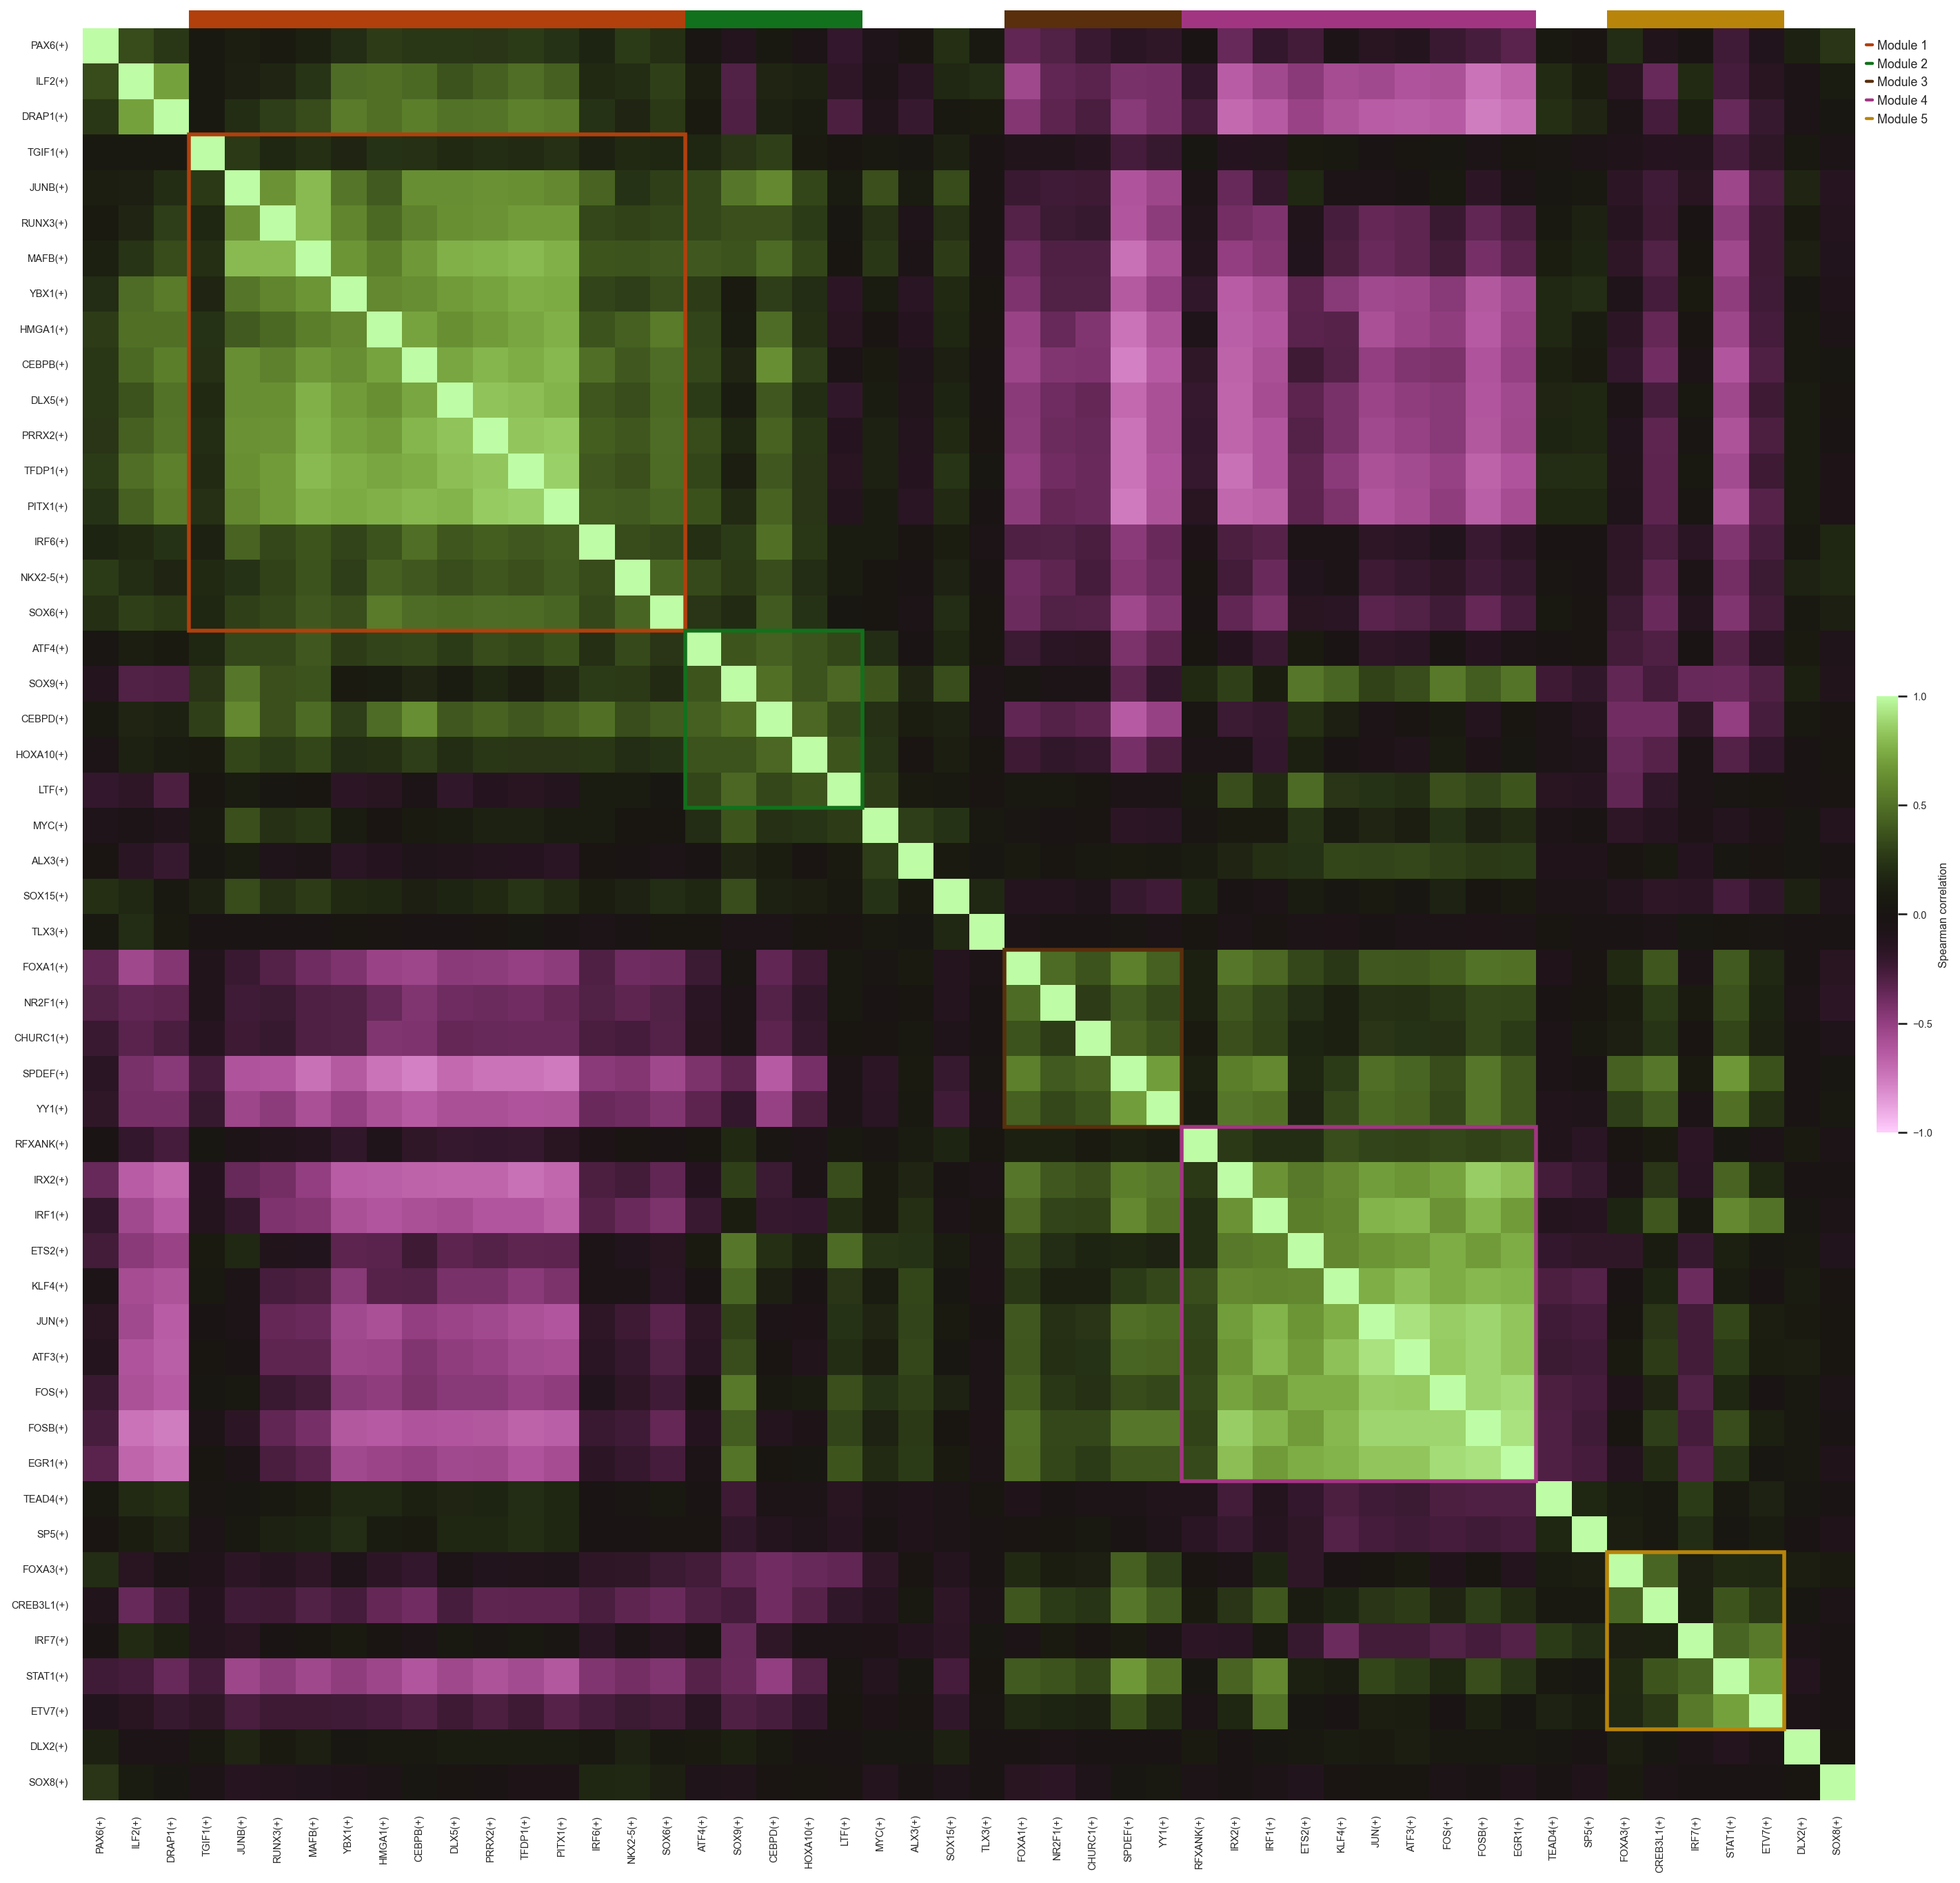

In [41]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Prepare AUC and select top regulons:
auc_mtx["type"] = adata.obs["type"]
mean_auc_by_type = auc_mtx.groupby("type").median()
del auc_mtx["type"]

top_n = 50
top_tfs = (
    mean_auc_by_type.max(axis=0).sort_values(ascending=False).head(top_n).index.tolist()
)
auc_mtx = auc_mtx[top_tfs]

# Correlation matrix:
correlation_matrix = auc_mtx.corr(method="spearman")
correlation_matrix = pd.DataFrame(
    np.nan_to_num(correlation_matrix), index=auc_mtx.columns, columns=auc_mtx.columns
)

# Hierarchical clustering-based module detection:
dist_matrix = 1 - correlation_matrix
pdist = spc.distance.squareform(dist_matrix.values, checks=False)
linkage = spc.linkage(pdist, method="complete")

# Infer modules by distance threshold:
threshold = 0.9
labels = spc.fcluster(linkage, threshold, criterion="distance")
modules = pd.Series(labels, index=correlation_matrix.columns, name="Module")
n_modules = modules.nunique()
print(f"Identified {n_modules} modules at distance threshold {threshold}")

# Reorder regulons by dendrogram:
dendro = spc.dendrogram(linkage, no_plot=True)
ordered_genes = [correlation_matrix.columns[i] for i in dendro["leaves"]]
correlation_matrix = correlation_matrix.loc[ordered_genes, ordered_genes]
ordered_modules = modules.loc[ordered_genes]

# Identify contiguous cluster spans:
spans = []
start = 0
current_label = ordered_modules.iloc[0]
for i, lbl in enumerate(ordered_modules):
    if lbl != current_label:
        spans.append((current_label, start, i))
        start = i
        current_label = lbl
spans.append((current_label, start, len(ordered_modules)))

# Colour maps:
palette = sns.color_palette("dark", n_modules)
module_color_map = dict(zip(sorted(ordered_modules.unique()), palette))

# Determine which modules will actually be plotted:
plotted_spans = []
plotted_labels = []
for cluster_label, start_idx, end_idx in spans:
    if end_idx - start_idx < 4:  # skip modules with <4 genes
        continue
    submatrix = correlation_matrix.iloc[start_idx:end_idx, start_idx:end_idx].copy()
    np.fill_diagonal(submatrix.values, np.nan)
    median_corr = np.nanmedian(submatrix.values)
    if np.isnan(median_corr) or abs(median_corr) < 0.3:
        continue
    plotted_spans.append((cluster_label, start_idx, end_idx))
    plotted_labels.append(cluster_label)

# Rename plotted modules sequentially:
label_map = {old: new + 1 for new, old in enumerate(sorted(set(plotted_labels)))}
module_color_map = {label_map[k]: module_color_map[k] for k in plotted_labels}
plotted_spans = [(label_map[cl], s, e) for cl, s, e in plotted_spans]

# Plot heatmap:
plt.figure(figsize=(20, 20))
sns.set_theme(style="white", font_scale=0.6)
ax = sns.heatmap(
    correlation_matrix,
    cmap="vanimo",
    square=True,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={
        "shrink": 0.2,
        "label": "Spearman correlation",
        "ticks": [-1, -0.5, 0, 0.5, 1],
        "pad": 0.01,
    },
    xticklabels=True,
    yticklabels=True,
)

# Draw module boundaries:
for cluster_label, start_idx, end_idx in plotted_spans:
    size = end_idx - start_idx
    color = module_color_map[cluster_label]
    ax.add_patch(
        Rectangle(
            (start_idx, start_idx),
            size,
            size,
            fill=False,
            edgecolor=color,
            linewidth=2.5,
            zorder=5,
        )
    )

# Top colour bar:
bar_ax = inset_axes(
    ax,
    width="100%",
    height="1%",
    loc="upper center",
    bbox_to_anchor=(0, 0.01, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
for cluster_label, start_idx, end_idx in plotted_spans:
    start_frac = start_idx / len(ordered_genes)
    width_frac = (end_idx - start_idx) / len(ordered_genes)
    color = module_color_map[cluster_label]
    bar_ax.add_patch(
        Rectangle(
            (start_frac, 0),
            width_frac,
            1,
            transform=bar_ax.transAxes,
            facecolor=color,
            edgecolor="none",
        )
    )
bar_ax.set_xticks([])
bar_ax.set_yticks([])
bar_ax.set_xlim(0, 1)
bar_ax.set_ylim(0, 1)
bar_ax.axis("off")

# Legend: only show plotted modules sequentially
legend_handles = [
    plt.Line2D([0], [0], color=module_color_map[m], lw=2, label=f"Module {m}")
    for m in sorted(module_color_map.keys())
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1, 1),
    ncol=1,
    frameon=False,
    fontsize=8,
)

plt.tight_layout()
plt.savefig(f"figures/{sample}_correlation_heatmap_modules.pdf", bbox_inches="tight")
plt.show()

In [42]:
top_tfs = ordered_modules.index.tolist()
# average AUC per regulon
mean_auc_by_type_top_n = mean_auc_by_type[[c for c in mean_auc_by_type.columns if c in top_tfs]]
mean_auc_by_type_top_n = mean_auc_by_type_top_n[top_tfs]
# write to file
outpath = os.path.join("results", f"{sample}_mean_auc_by_type_top_n.csv")
mean_auc_by_type_top_n.T.to_csv(outpath)

In [43]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

normalizing counts per cell


    finished (0:00:00)


In [44]:
# extract top regulons without (+)
tf_names = [gene.rstrip("(+)") for gene in top_tfs]
adata_top_tfs = adata[:, adata.var_names.isin(tf_names)]

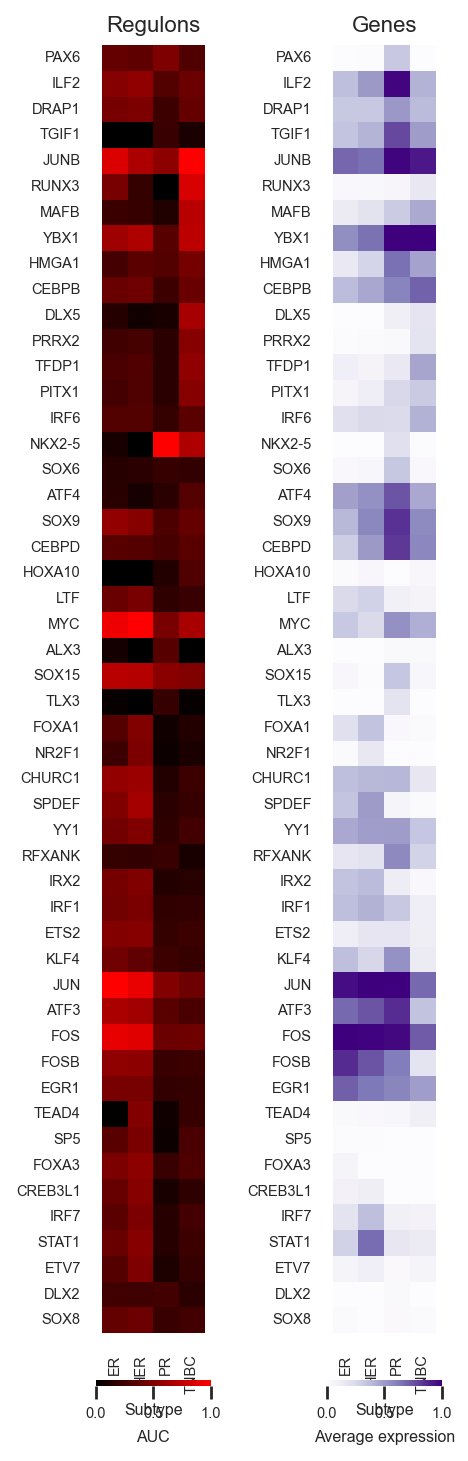

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec

# Ensure common rows (samples/cells):
mean_auc_by_type_top_n.columns = mean_auc_by_type_top_n.columns.str.replace(r"\(\+\)", "", regex=True)
common_rows = mean_auc_by_type_top_n.columns.intersection(adata_top_tfs.var_names)

data1 = mean_auc_by_type_top_n.T.loc[common_rows]

# rescale between 0 and 1 for better visualisation
data1 = (data1 - data1.min()) / (data1.max() - data1.min())

groupby = "type"
gene_list = tf_names
cmap = cmap_aucell

# Prepare matrixplot aggregated by group:
expr_df = pd.DataFrame(
    adata[:, gene_list].X.toarray() if hasattr(adata.X, "toarray") else adata[:, gene_list].X,
    index=adata.obs_names,
    columns=gene_list,
)

# scale expression data per gene for better visualisation
expr_df = (expr_df - expr_df.min()) / (expr_df.max() - expr_df.min())

# Aggregate by group
group_means = expr_df.groupby(adata.obs[groupby]).mean()
group_means = group_means.T  # genes x groups, vertical orientation

# scale between 0 and 1 for better visualisation per gene
group_means = (group_means - group_means.min()) / (group_means.max() - group_means.min())

# Figure size:
fig_height = max(data1.shape[1], len(gene_list)) * 0.2

gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(3, fig_height))

# First heatmap:
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    data1,
    ax=ax0,
    cmap=cmap_aucell,
    cbar=True,
    square=True,
    yticklabels=True,
    xticklabels=True,
    cbar_kws={
        "label": "AUC",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.03,
    },
    vmin=0,
    vmax=1,
)
ax0.set_title("Regulons", fontsize=10)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)
ax0.set_xlabel("Subtype")

# --- Second heatmap (matrixplot aggregated) ---
ax1 = fig.add_subplot(gs[0, 1])
sns.heatmap(
    group_means,
    ax=ax1,
    cmap="Purples",
    cbar=True,
    cbar_kws={
        "label": "Average expression",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.03,
    },
    square=True,
    yticklabels=True,
    xticklabels=True,
    vmin=0,
    vmax=1,
)
ax1.set_title("Genes", fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
ax1.set_xlabel("Subtype")

plt.subplots_adjust(left=0.05, right=0.95, wspace=0)
plt.tight_layout(pad=0)
plt.savefig(f"figures/{sample}_regulon_gene_expression_heatmap.pdf", bbox_inches="tight")
plt.show()

In [46]:
# load the motifs
df_motifs = load_motifs(f"results/{sample}_motifs.csv")
# derive regulons
regulons = derive_regulons(df_motifs)

with open(f"results/{sample}_oren_motifs.dat", "wb") as f:
    pickle.dump(regulons, f)

# rename regulons
auc_mtx.columns = auc_mtx.columns.str.replace("\(\+\)", "")
# add metadata to AnnData
add_scenic_metadata(adata, auc_mtx, regulons)

Create regulons from a dataframe of enriched features.
Additional columns saved: []


AnnData object with n_obs × n_vars = 5628 × 19465
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'type', 'patient', 'annotation', 'percent.mt', 'Phase', 'CC.Difference', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'integrated_snn_res.2', 'celltype', 'malignancy', 'cellclass', 'quiescence_score', 'cycling_state', 'QuiescenceType', 'disease', 'ident', 'oren_quiescence', 'cycling_state_oren', 'Regulon(NKX2-5(+))', 'Regulon(JUNB(+))', 'Regulon(RUNX3(+))', 'Regulon(SOX15(+))', 'Regulon(YBX1(+))', 'Regulon(JUN(+))', 'Regulon(MAFB(+))', 'Regulon(PAX6(+))', 'Regulon(MYC(+))', 'Regulon(DLX5(+))', 'Regulon(FOS(+))', 'Regulon(TFDP1(+))', 'Regulon(PITX1(+))', 'Regulon(PRRX2(+))', 'Regulon(ATF3(+))', 'Regulon(ALX3(+))', 'Regulon(ILF2(+))', 'Regulon(HMGA1(+))', 'Regulon(SOX9(+))', 'Regulon(SPDEF(+))', 'Regulon(CEBPB(+))', 'Regulon(CEBPD(+))', 'Regulon(CHURC1(+))', 'Regulon(DRAP1(+))', 'Regulon(FOSB(+))', 'Regulon(DLX2(+))', 'Regulon(ETS2(+))', 'Regulon(FOXA3(+))', 'Regulon(IRF6(+))', 'Reg

In [47]:
# calculate regulon specificity scores
rss_score = regulon_specificity_scores(auc_mtx, adata.obs.type)

def regulon_to_gene(reg_name):
    return reg_name.split("(")[0]

expressed_regulons = []
for reg in rss_score.columns:
    base_gene = regulon_to_gene(reg)
    if base_gene in adata.var_names:
        if (rss_score[reg] > 0.6).any() and (adata[:, base_gene].X > 0.1).sum() > 0:
            expressed_regulons.append(reg)

# Create a new list with converted gene names
regulon_names = [convert_gene_name(gene) for gene in expressed_regulons]

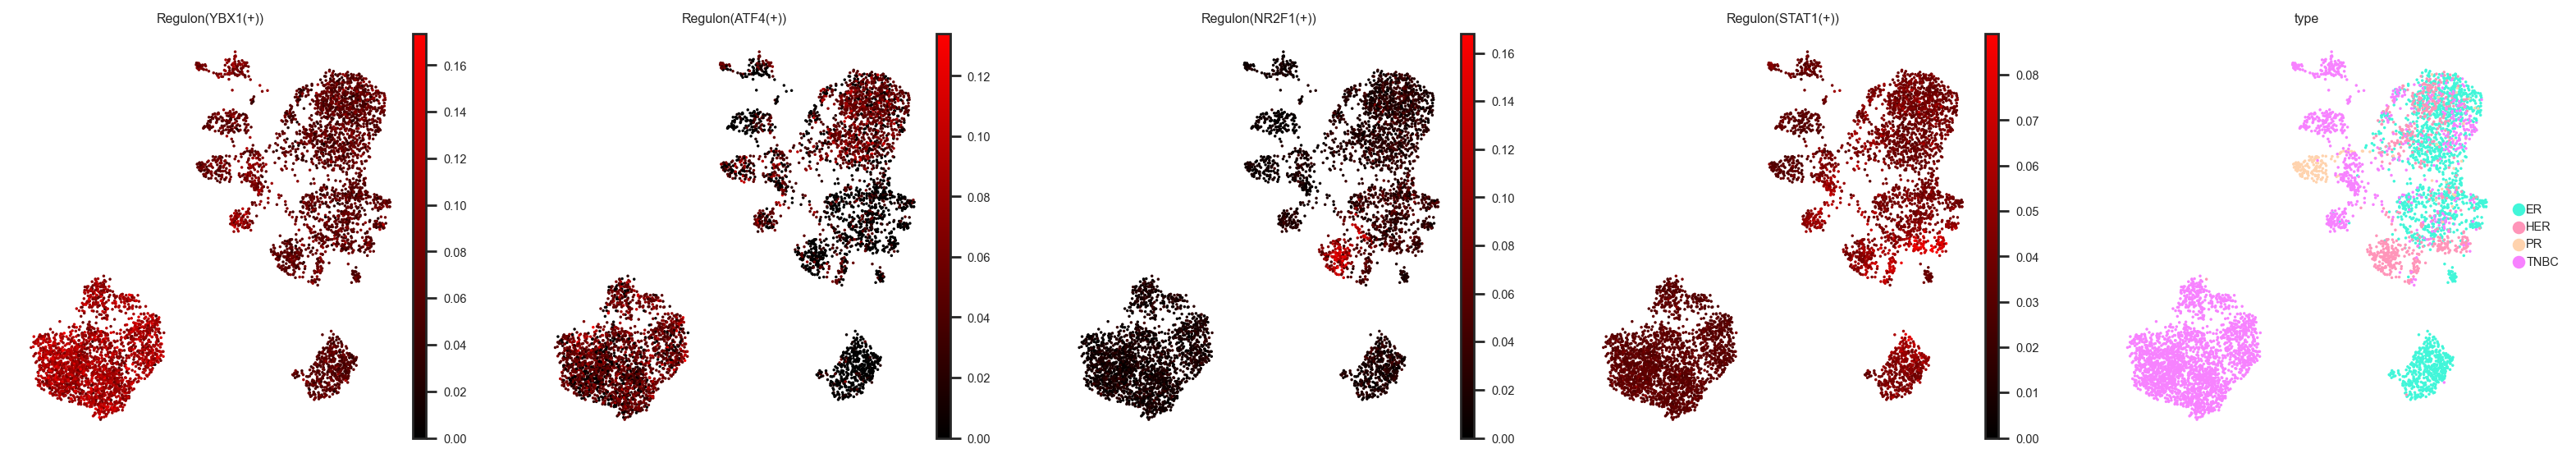

In [48]:
regulon_names = ["Regulon(YBX1(+))", "Regulon(ATF4(+))", "Regulon(NR2F1(+))", "Regulon(STAT1(+))"]
# plot them on the new embedding space
sc.pl.embedding(
    adata,
    basis="X_umap_aucell",
    color=regulon_names,
    title=regulon_names.append("type"),
    palette=cmap_type,
    cmap=cmap_aucell,
    sort_order=False,
    vmax="p99.9",
    vmin=0,
    size=10,
    ncols=5,
    save=f"_{sample}_rss_regulon_activity.pdf",
)

In [49]:
rss_g0 = regulon_specificity_scores(auc_mtx, adata.obs.type)

### Transcription factors in fast-cycling cells

In [50]:
sample = "Fast-cycling"

In [51]:
adata = adata_invasive[adata_invasive.obs.cycling_state_oren.isin([sample])].copy()
adata.X.max()

5668.0

In [52]:
sc.pp.filter_genes(adata, min_cells=10)

filtered out 2103 genes that are detected in less than 10 cells


In [53]:
loom_path = os.path.join(resource_dir, f"{sample}_input.loom")
loom_path_output = os.path.join(resource_dir, f"{sample}_output.loom")
loom_path_aucell = os.path.join(resource_dir, f"{sample}_aucell.loom")

In [54]:
tfs = [tf.strip() for tf in open(tfs_path)]
print(f"{np.sum(adata.var.index.isin(tfs))} / {len(tfs)} TFs are found in the object")

1683 / 1892 TFs are found in the object


In [55]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e4)
adata_log.X = np.log1p(adata_log.X)

normalizing counts per cell
    finished (0:00:00)


In [56]:
use_hvg = False

if use_hvg:
    mask = (adata.var["highly_variable"]) | adata.var.index.isin(tfs)
    adata = adata[:, mask]

In [57]:
# raw data to loom
row_attributes = {"Gene": np.array(adata.var.index)}
col_attributes = {
    "CellID": np.array(adata.obs.index),
    "nGene": np.array(np.sum(adata.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata.X.transpose(), axis=0)).flatten()
}
lp.create(loom_path, adata.X.transpose().toarray(), row_attributes, col_attributes)

In [58]:
num_workers = 32

outpath_adj = os.path.join(results_dir, f"{sample}_adjacencies.csv")
if not os.path.exists(outpath_adj):
    !pyscenic grn {loom_path} {tfs_path} -o $outpath_adj \
      --num_workers {num_workers} \
      --seed 0 \
      --method grnboost2

In [59]:
# see the top TF-target gene associations
adjacencies = pd.read_csv(outpath_adj, index_col=False, sep=",")
print(f"Number of associations: {adjacencies.shape[0]}")
adjacencies.head()

Number of associations: 1817761


,TF,target,importance
0,RPS4X,RPL13A,25.920624
1,RPL6,RPL13A,25.185979
2,RPS4X,RPL10A,24.192533
3,RPL6,RPL32,23.860883
4,RPL6,RPL41,23.663944


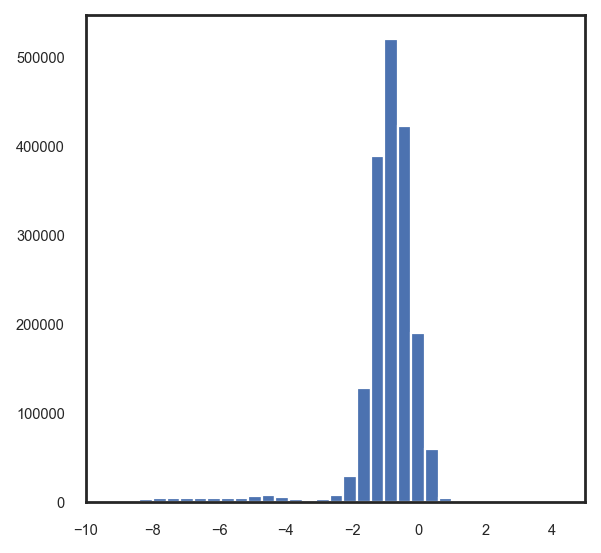

In [60]:
# visualise the distribution of weights
plt.hist(np.log10(adjacencies["importance"]), bins=50)
plt.xlim([-10, 5])
plt.grid(False)

In [61]:
# load TSS annotations
db_glob = "auxiliaries/*feather"
db_names = " ".join(glob.glob(db_glob))

In [62]:
# run the context-specific co-expression network inference
outpath_motifs = results_dir + f"/{sample}_motifs.csv"

if not os.path.exists(outpath_motifs):
    !pyscenic ctx $outpath_adj $db_names \
      --annotations_fname "auxiliaries/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl" \
      --expression_mtx_fname {loom_path} \
      --output {outpath_motifs} \
      --mask_dropouts \
      --num_workers {num_workers}

In [63]:
# Count detected genes per cell
if issparse(adata.X):
    n_genes_detected_per_cell = np.array((adata.X > 0).sum(axis=1)).ravel()
else:
    n_genes_detected_per_cell = (adata.X > 0).sum(axis=1)

# Compute percentiles
percentiles = pd.Series(n_genes_detected_per_cell).quantile([0.01, 0.05, 0.10, 0.50, 1])
print(percentiles)

0.01    1018.0
0.05    1091.0
0.10    1185.0
0.50    2074.5
1.00    6810.0
dtype: float64


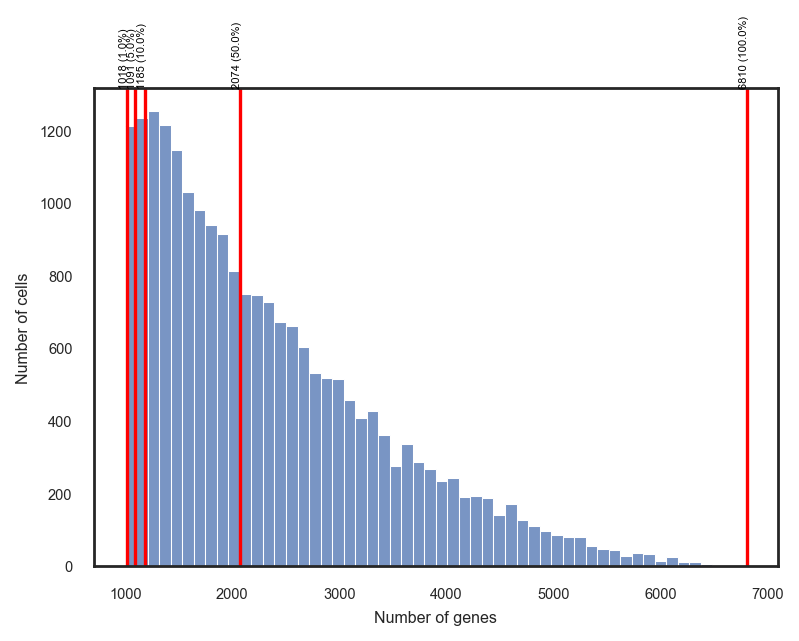

In [64]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Plot histogram
sns.histplot(
    n_genes_detected_per_cell,
    bins="fd",
    stat="count",
    kde=False,
    ax=ax,
)

# Add percentile lines and labels
for i, x in enumerate(percentiles):
    ax.axvline(x=x, color="red")
    ax.text(
        x=x,
        y=ax.get_ylim()[1],
        s=f"{int(x)} ({percentiles.index.values[i] * 100}%)",
        color="black",
        rotation=90,
        size="x-small",
        rotation_mode="anchor",
    )

# Final styling
ax.set_xlabel("Number of genes")
ax.set_ylabel("Number of cells")
fig.tight_layout()
plt.grid(False)

In [65]:
# log1p transformed data to loom for AUCell
row_attributes = {"Gene": np.array(adata_log.var.index)}
col_attributes = {
    "CellID": np.array(adata_log.obs.index),
    "nGene": np.array(np.sum(adata_log.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata_log.X.transpose(), axis=0)).flatten(),
}
aucell_path = "resources/G0_log1p_normalised.loom"
lp.create(aucell_path, adata_log.X.transpose().toarray(), row_attributes, col_attributes)

In [66]:
# monkey patch for older numpy versions

# if not hasattr(np, "msort"):
#     np.msort = np.sort  # np.sort(axis=0) behaves like msort
# if not hasattr(np, "float"):
#     np.float = float

In [67]:
motif_path = f"results/{sample}_motifs.csv"

In [68]:
if not os.path.exists(loom_path_output):
    !pyscenic aucell $aucell_path $motif_path \
      --output {loom_path_output} \
      --num_workers {num_workers} \
      --seed 0

In [69]:
lf = lp.connect(loom_path_output, mode="r+", validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [70]:
# add metadata to the adata
ad_auc_mtx = ad.AnnData(auc_mtx)
sc.pp.neighbors(ad_auc_mtx, n_neighbors=10, metric="correlation")
sc.tl.umap(ad_auc_mtx)
# add to the adata
adata.obsm["X_umap_aucell"] = ad_auc_mtx.obsm["X_umap"]

computing neighbors
computing PCA
    with n_comps=50
    finished (0:00:00)
    finished (0:00:03)
computing UMAP
    finished (0:00:13)


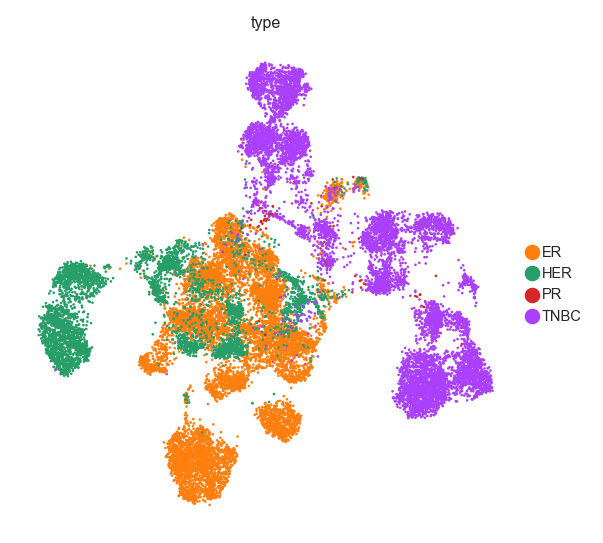

In [71]:
# visualise the new embedding space
sc.pl.embedding(adata, basis="X_umap_aucell", color="type")

In [72]:
# Create the colormap
cmap_aucell = LinearSegmentedColormap.from_list("black_to_red", ["black", "red"])
cmap_type = ["#41F6D9", "#FFD3AE", "#FF95B9", "#F782FF"]

Identified 12 modules at distance threshold 0.9


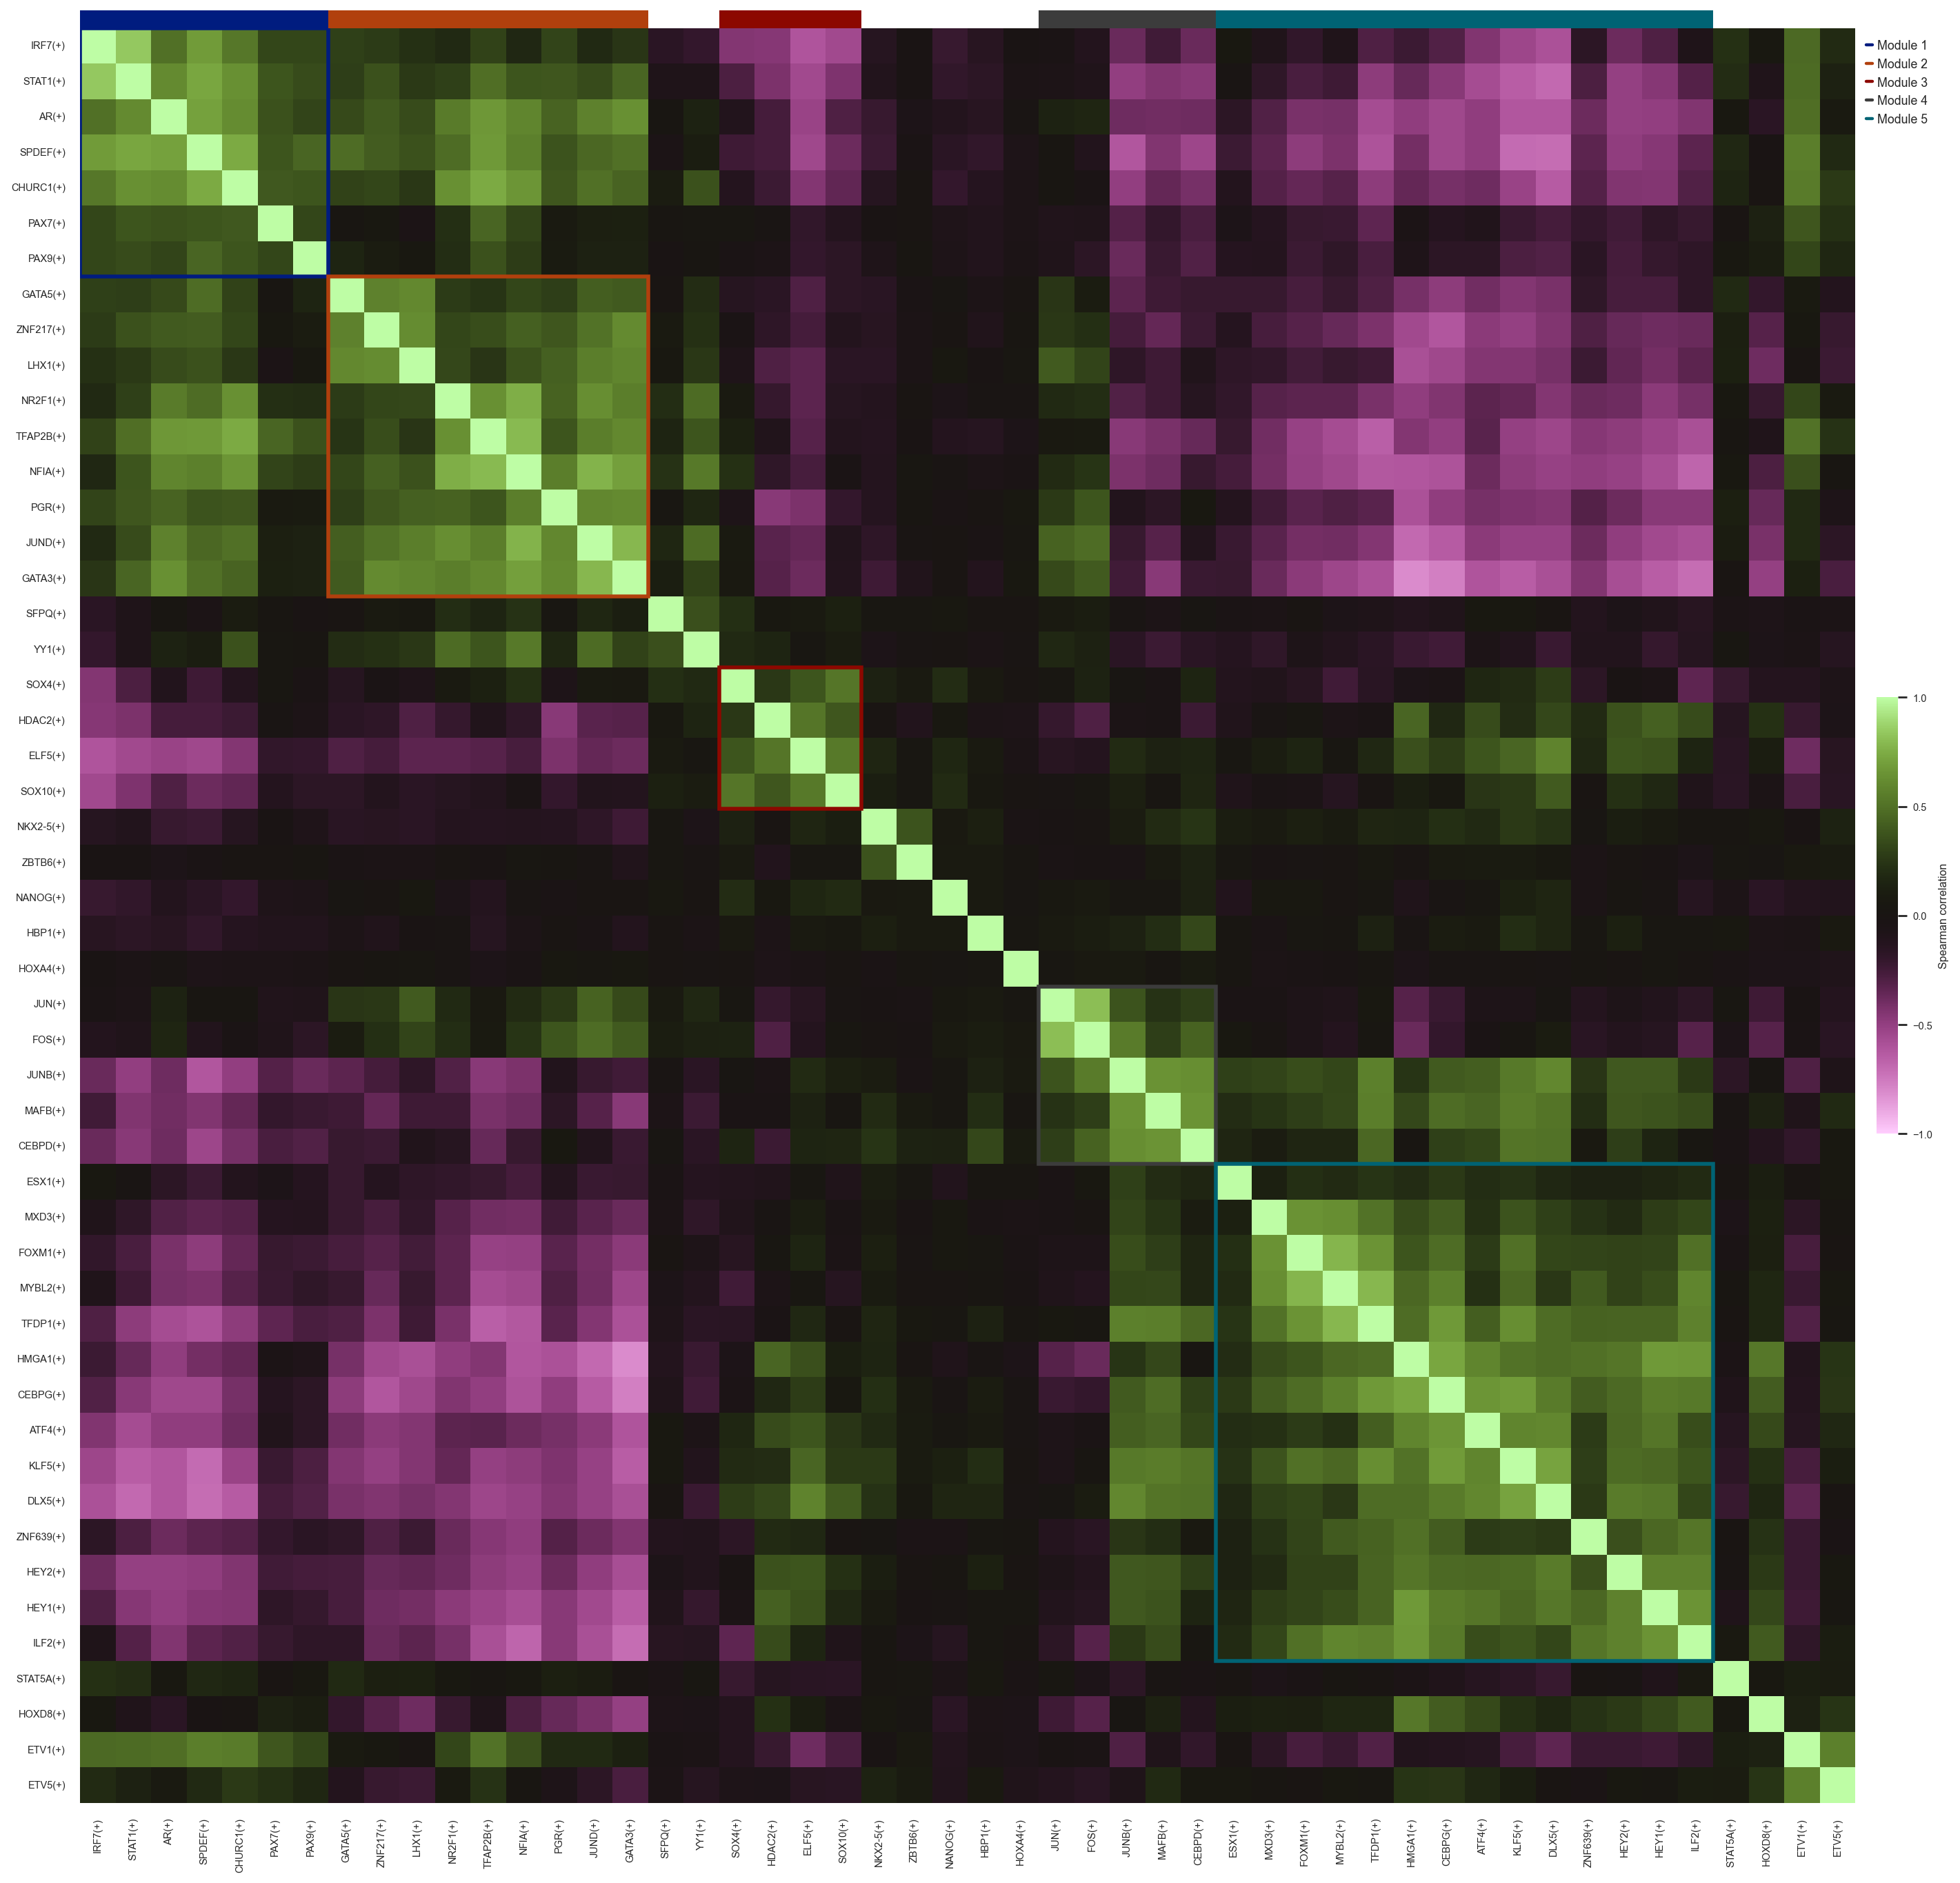

In [73]:
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as spc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Prepare AUC and select top regulons:
auc_mtx["type"] = adata.obs["type"]
mean_auc_by_type = auc_mtx.groupby("type").median()
del auc_mtx["type"]

top_n = 50
top_tfs = (
    mean_auc_by_type.max(axis=0).sort_values(ascending=False).head(top_n).index.tolist()
)
auc_mtx = auc_mtx[top_tfs]

# Correlation matrix:
correlation_matrix = auc_mtx.corr(method="spearman")
correlation_matrix = pd.DataFrame(
    np.nan_to_num(correlation_matrix), index=auc_mtx.columns, columns=auc_mtx.columns
)

# Hierarchical clustering-based module detection:
dist_matrix = 1 - correlation_matrix
pdist = spc.distance.squareform(dist_matrix.values, checks=False)
linkage = spc.linkage(pdist, method="complete")

# Infer modules by distance threshold:
threshold = 0.9
labels = spc.fcluster(linkage, threshold, criterion="distance")
modules = pd.Series(labels, index=correlation_matrix.columns, name="Module")
n_modules = modules.nunique()
print(f"Identified {n_modules} modules at distance threshold {threshold}")

# Reorder regulons by dendrogram:
dendro = spc.dendrogram(linkage, no_plot=True)
ordered_genes = [correlation_matrix.columns[i] for i in dendro["leaves"]]
correlation_matrix = correlation_matrix.loc[ordered_genes, ordered_genes]
ordered_modules = modules.loc[ordered_genes]

# Identify contiguous cluster spans:
spans = []
start = 0
current_label = ordered_modules.iloc[0]
for i, lbl in enumerate(ordered_modules):
    if lbl != current_label:
        spans.append((current_label, start, i))
        start = i
        current_label = lbl
spans.append((current_label, start, len(ordered_modules)))

# Colour maps:
palette = sns.color_palette("dark", n_modules)
module_color_map = dict(zip(sorted(ordered_modules.unique()), palette))

# Determine which modules will actually be plotted:
plotted_spans = []
plotted_labels = []
for cluster_label, start_idx, end_idx in spans:
    if end_idx - start_idx < 4:  # skip modules with <4 genes
        continue
    submatrix = correlation_matrix.iloc[start_idx:end_idx, start_idx:end_idx].copy()
    np.fill_diagonal(submatrix.values, np.nan)
    median_corr = np.nanmedian(submatrix.values)
    if np.isnan(median_corr) or abs(median_corr) < 0.3:
        continue
    plotted_spans.append((cluster_label, start_idx, end_idx))
    plotted_labels.append(cluster_label)

# Rename plotted modules sequentially:
label_map = {old: new + 1 for new, old in enumerate(sorted(set(plotted_labels)))}
module_color_map = {label_map[k]: module_color_map[k] for k in plotted_labels}
plotted_spans = [(label_map[cl], s, e) for cl, s, e in plotted_spans]

# Plot heatmap:
plt.figure(figsize=(20, 20))
sns.set_theme(style="white", font_scale=0.6)
ax = sns.heatmap(
    correlation_matrix,
    cmap="vanimo",
    square=True,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={
        "shrink": 0.2,
        "label": "Spearman correlation",
        "ticks": [-1, -0.5, 0, 0.5, 1],
        "pad": 0.01,
    },
    xticklabels=True,
    yticklabels=True,
)

# Draw module boundaries:
for cluster_label, start_idx, end_idx in plotted_spans:
    size = end_idx - start_idx
    color = module_color_map[cluster_label]
    ax.add_patch(
        Rectangle(
            (start_idx, start_idx),
            size,
            size,
            fill=False,
            edgecolor=color,
            linewidth=2.5,
            zorder=5,
        )
    )

# Top colour bar:
bar_ax = inset_axes(
    ax,
    width="100%",
    height="1%",
    loc="upper center",
    bbox_to_anchor=(0, 0.01, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
for cluster_label, start_idx, end_idx in plotted_spans:
    start_frac = start_idx / len(ordered_genes)
    width_frac = (end_idx - start_idx) / len(ordered_genes)
    color = module_color_map[cluster_label]
    bar_ax.add_patch(
        Rectangle(
            (start_frac, 0),
            width_frac,
            1,
            transform=bar_ax.transAxes,
            facecolor=color,
            edgecolor="none",
        )
    )
bar_ax.set_xticks([])
bar_ax.set_yticks([])
bar_ax.set_xlim(0, 1)
bar_ax.set_ylim(0, 1)
bar_ax.axis("off")

# Legend: only show plotted modules sequentially
legend_handles = [
    plt.Line2D([0], [0], color=module_color_map[m], lw=2, label=f"Module {m}")
    for m in sorted(module_color_map.keys())
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1, 1),
    ncol=1,
    frameon=False,
    fontsize=8,
)

plt.tight_layout()
plt.savefig(f"figures/{sample}_correlation_heatmap_modules.pdf", bbox_inches="tight")
plt.show()

In [74]:
top_tfs = ordered_modules.index.tolist()
# average AUC per regulon
mean_auc_by_type_top_n = mean_auc_by_type[
    [c for c in mean_auc_by_type.columns if c in top_tfs]
]
mean_auc_by_type_top_n = mean_auc_by_type_top_n[top_tfs]
# write to file
outpath = os.path.join("results", f"{sample}_mean_auc_by_type_top_n.csv")
mean_auc_by_type_top_n.T.to_csv(outpath)

In [75]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

normalizing counts per cell
    finished (0:00:00)


In [76]:
# extract top regulons without (+)
tf_names = [gene.rstrip("(+)") for gene in top_tfs]
adata_top_tfs = adata[:, adata.var_names.isin(tf_names)]

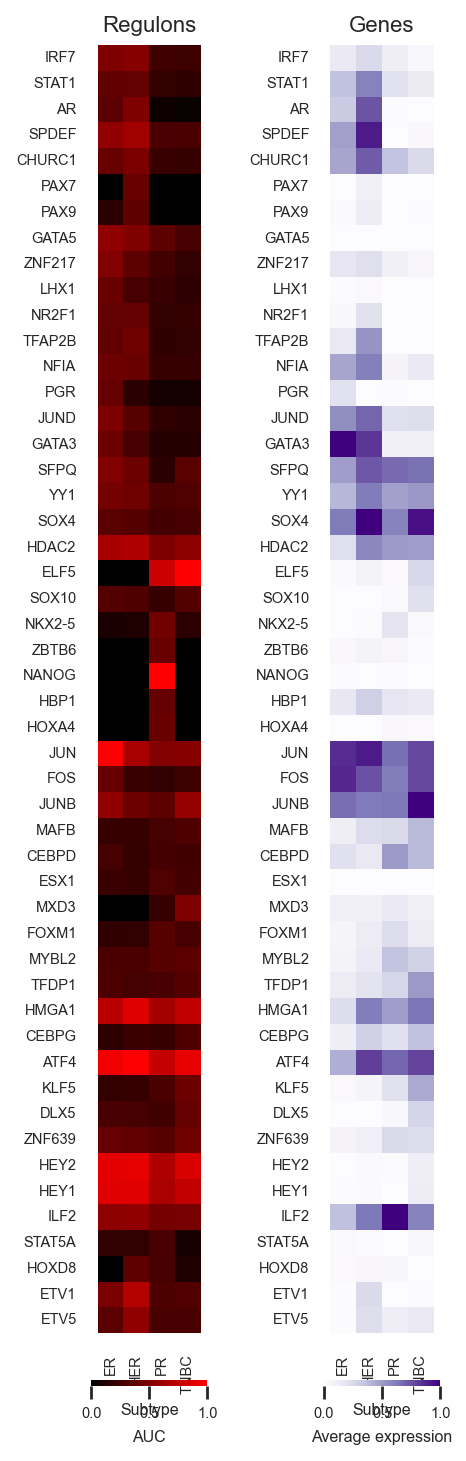

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec

# Ensure common rows (samples/cells):
mean_auc_by_type_top_n.columns = mean_auc_by_type_top_n.columns.str.replace(r"\(\+\)", "", regex=True)
common_rows = mean_auc_by_type_top_n.columns.intersection(adata_top_tfs.var_names)

data1 = mean_auc_by_type_top_n.T.loc[common_rows]

# rescale between 0 and 1 for better visualisation
data1 = (data1 - data1.min()) / (data1.max() - data1.min())

groupby = "type"
gene_list = tf_names
cmap = cmap_aucell

# Prepare matrixplot aggregated by group:
expr_df = pd.DataFrame(
    adata[:, gene_list].X.toarray() if hasattr(adata.X, "toarray") else adata[:, gene_list].X,
    index=adata.obs_names,
    columns=gene_list,
)

# scale expression data per gene for better visualisation
expr_df = (expr_df - expr_df.min()) / (expr_df.max() - expr_df.min())

# Aggregate by group
group_means = expr_df.groupby(adata.obs[groupby]).mean()
group_means = group_means.T  # genes x groups, vertical orientation

# scale between 0 and 1 for better visualisation per gene
group_means = (group_means - group_means.min()) / (group_means.max() - group_means.min())

# Figure size:
fig_height = max(data1.shape[1], len(gene_list)) * 0.2

gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(3, fig_height))

# First heatmap:
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    data1,
    ax=ax0,
    cmap=cmap_aucell,
    cbar=True,
    square=True,
    yticklabels=True,
    xticklabels=True,
    cbar_kws={
        "label": "AUC",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.03,
    },
    vmin=0,
    vmax=1,
)
ax0.set_title("Regulons", fontsize=10)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)
ax0.set_xlabel("Subtype")

# --- Second heatmap (matrixplot aggregated) ---
ax1 = fig.add_subplot(gs[0, 1])
sns.heatmap(
    group_means,
    ax=ax1,
    cmap="Purples",
    cbar=True,
    cbar_kws={
        "label": "Average expression",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.03,
    },
    square=True,
    yticklabels=True,
    xticklabels=True,
    vmin=0,
    vmax=1,
)
ax1.set_title("Genes", fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
ax1.set_xlabel("Subtype")

plt.subplots_adjust(left=0.05, right=0.95, wspace=0)
plt.tight_layout(pad=0)
plt.savefig(f"figures/{sample}_regulon_gene_expression_heatmap.pdf", bbox_inches="tight")
plt.show()

In [78]:
# load the motifs
df_motifs = load_motifs(f"results/{sample}_motifs.csv")
# derive regulons
regulons = derive_regulons(df_motifs)

with open(f"results/{sample}_oren_motifs.dat", "wb") as f:
    pickle.dump(regulons, f)

# rename regulons
auc_mtx.columns = auc_mtx.columns.str.replace("\(\+\)", "")
# add metadata to AnnData
add_scenic_metadata(adata, auc_mtx, regulons)

Create regulons from a dataframe of enriched features.
Additional columns saved: []


AnnData object with n_obs × n_vars = 21514 × 21796
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'type', 'patient', 'annotation', 'percent.mt', 'Phase', 'CC.Difference', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'integrated_snn_res.2', 'celltype', 'malignancy', 'cellclass', 'quiescence_score', 'cycling_state', 'QuiescenceType', 'disease', 'ident', 'oren_quiescence', 'cycling_state_oren', 'Regulon(NANOG(+))', 'Regulon(ELF5(+))', 'Regulon(ATF4(+))', 'Regulon(HEY2(+))', 'Regulon(HEY1(+))', 'Regulon(HMGA1(+))', 'Regulon(JUN(+))', 'Regulon(JUNB(+))', 'Regulon(HDAC2(+))', 'Regulon(ETV1(+))', 'Regulon(MXD3(+))', 'Regulon(ILF2(+))', 'Regulon(NKX2-5(+))', 'Regulon(SPDEF(+))', 'Regulon(ZBTB6(+))', 'Regulon(HOXA4(+))', 'Regulon(ZNF639(+))', 'Regulon(ETV5(+))', 'Regulon(HBP1(+))', 'Regulon(KLF5(+))', 'Regulon(GATA5(+))', 'Regulon(IRF7(+))', 'Regulon(DLX5(+))', 'Regulon(AR(+))', 'Regulon(ZNF217(+))', 'Regulon(FOXM1(+))', 'Regulon(MYBL2(+))', 'Regulon(SFPQ(+))', 'Regulon(CHURC1(+))', '

In [79]:
# calculate regulon specificity scores
rss_score = regulon_specificity_scores(auc_mtx, adata.obs.type)

def regulon_to_gene(reg_name):
    return reg_name.split("(")[0]

expressed_regulons = []
for reg in rss_score.columns:
    base_gene = regulon_to_gene(reg)
    if base_gene in adata.var_names:
        if (rss_score[reg] > 0.6).any() and (adata[:, base_gene].X > 0.1).sum() > 0:
            expressed_regulons.append(reg)

# Create a new list with converted gene names
regulon_names = [convert_gene_name(gene) for gene in expressed_regulons]

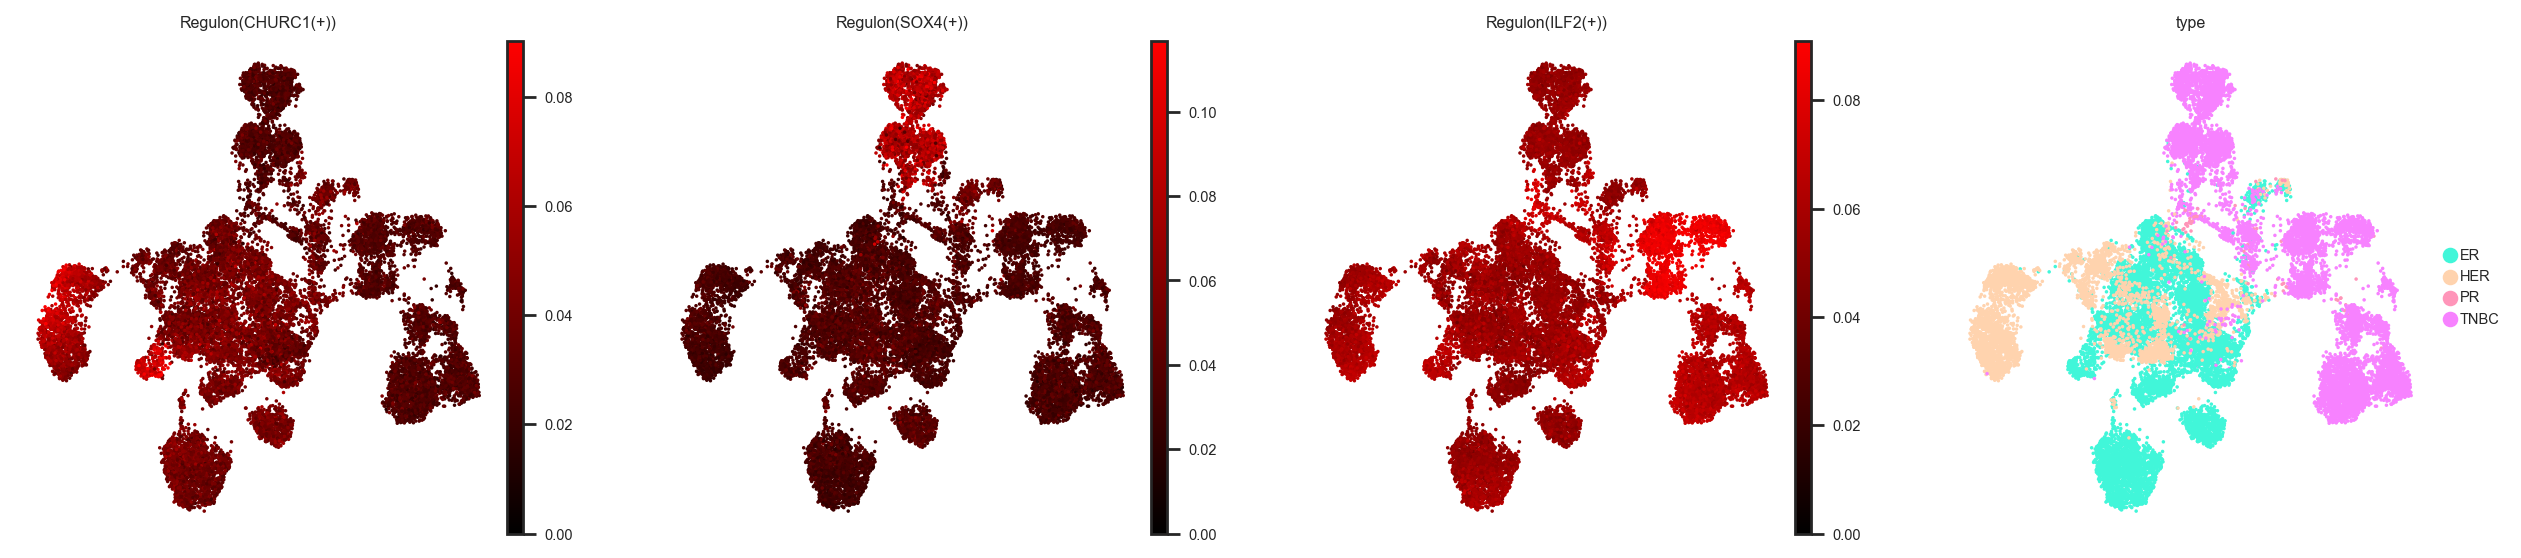

In [80]:
regulon_names = [
    "Regulon(CHURC1(+))",
    "Regulon(SOX4(+))",
    "Regulon(ILF2(+))",
]
# plot them on the new embedding space
sc.pl.embedding(
    adata,
    basis="X_umap_aucell",
    color=regulon_names,
    title=regulon_names.append("type"),
    palette=cmap_type,
    cmap=cmap_aucell,
    sort_order=False,
    vmax="p99.9",
    vmin=0,
    size=10,
    ncols=5,
    save=f"_{sample}_rss_regulon_activity.pdf",
)

In [81]:
rss_fast = regulon_specificity_scores(auc_mtx, adata.obs.type)
cats = ["ER", "PR", "HER", "TNBC"]

### Transcription factors in slow-cycling cells

In [82]:
sample = "Slow-cycling"

In [83]:
adata = adata_invasive[adata_invasive.obs.cycling_state_oren.isin([sample])].copy()
adata.X.max()

9101.0

In [84]:
sc.pp.filter_genes(adata, min_cells=10)

filtered out 1096 genes that are detected in less than 10 cells


In [85]:
loom_path = os.path.join(resource_dir, f"{sample}_input.loom")
loom_path_output = os.path.join(resource_dir, f"{sample}_output.loom")
loom_path_aucell = os.path.join(resource_dir, f"{sample}_aucell.loom")

In [86]:
tfs = [tf.strip() for tf in open(tfs_path)]
print(f"{np.sum(adata.var.index.isin(tfs))} / {len(tfs)} TFs are found in the object")

1703 / 1892 TFs are found in the object


In [87]:
adata_log = adata.copy()
sc.pp.normalize_total(adata_log, target_sum=1e4)
adata_log.X = np.log1p(adata_log.X)

normalizing counts per cell
    finished (0:00:00)


In [88]:
use_hvg = False

if use_hvg:
    mask = (adata.var["highly_variable"]) | adata.var.index.isin(tfs)
    adata = adata[:, mask]

In [89]:
# raw data to loom
row_attributes = {"Gene": np.array(adata.var.index)}
col_attributes = {
    "CellID": np.array(adata.obs.index),
    "nGene": np.array(np.sum(adata.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata.X.transpose(), axis=0)).flatten()
}
lp.create(loom_path, adata.X.transpose().toarray(), row_attributes, col_attributes)

In [90]:
num_workers = 32

outpath_adj = os.path.join(results_dir, f"{sample}_adjacencies.csv")
if not os.path.exists(outpath_adj):
    !pyscenic grn {loom_path} {tfs_path} -o $outpath_adj \
      --num_workers {num_workers} \
      --seed 0 \
      --method grnboost2

In [91]:
# see the top TF-target gene associations
adjacencies = pd.read_csv(outpath_adj, index_col=False, sep=",")
print(f"Number of associations: {adjacencies.shape[0]}")
adjacencies.head()

Number of associations: 1788205


,TF,target,importance
0,RPL35,FAU,25.862112
1,RPL35,RPL32,25.187632
2,YBX1,UQCRH,22.010403
3,RPS4X,RPL10A,21.946682
4,RPS4X,RPL10,20.755009


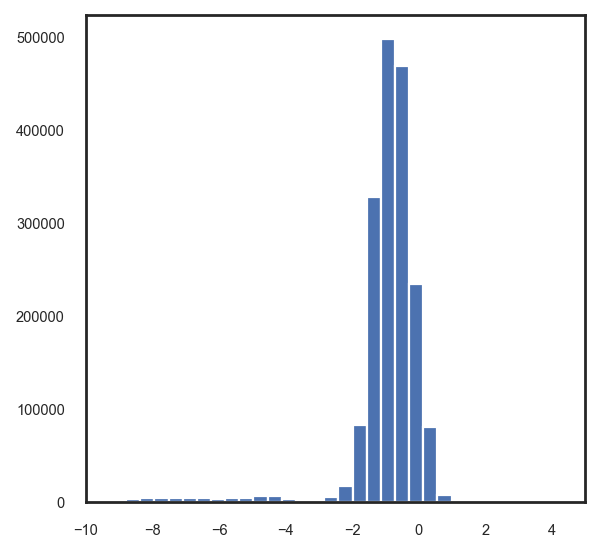

In [92]:
# visualise the distribution of weights
plt.hist(np.log10(adjacencies["importance"]), bins=50)
plt.xlim([-10, 5])
plt.grid(False)

In [93]:
# load TSS annotations
db_glob = "auxiliaries/*feather"
db_names = " ".join(glob.glob(db_glob))

In [94]:
# run the context-specific co-expression network inference
outpath_motifs = results_dir + f"/{sample}_motifs.csv"

if not os.path.exists(outpath_motifs):
    !pyscenic ctx $outpath_adj $db_names \
      --annotations_fname "auxiliaries/motifs-v10nr_clust-nr.hgnc-m0.001-o0.0.tbl" \
      --expression_mtx_fname {loom_path} \
      --output {outpath_motifs} \
      --mask_dropouts \
      --num_workers {num_workers}

In [95]:
# Count detected genes per cell
if issparse(adata.X):
    n_genes_detected_per_cell = np.array((adata.X > 0).sum(axis=1)).ravel()
else:
    n_genes_detected_per_cell = (adata.X > 0).sum(axis=1)

# Compute percentiles
percentiles = pd.Series(n_genes_detected_per_cell).quantile([0.01, 0.05, 0.10, 0.50, 1])
print(percentiles)

0.01    1015.0
0.05    1081.0
0.10    1160.0
0.50    1876.0
1.00    6959.0
dtype: float64


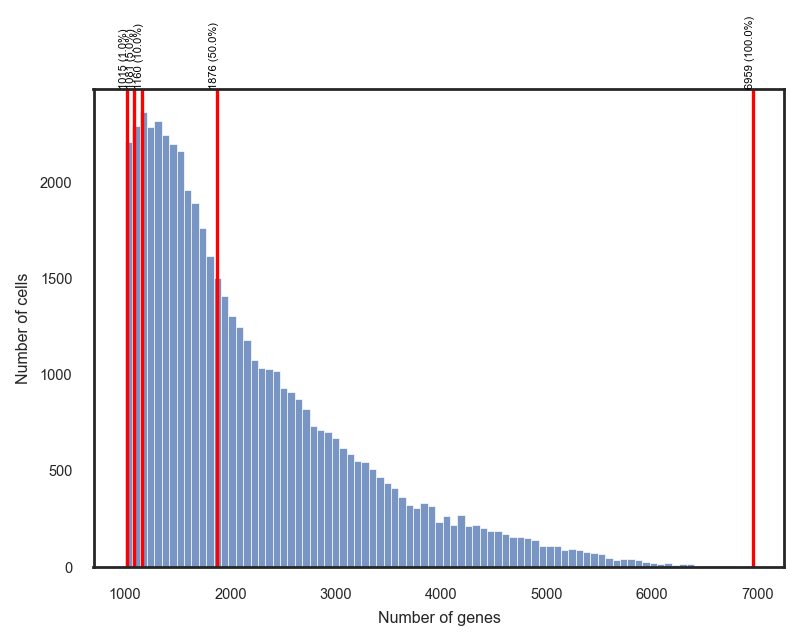

In [96]:
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Plot histogram
sns.histplot(
    n_genes_detected_per_cell,
    bins="fd",
    stat="count",
    kde=False,
    ax=ax,
)

# Add percentile lines and labels
for i, x in enumerate(percentiles):
    ax.axvline(x=x, color="red")
    ax.text(
        x=x,
        y=ax.get_ylim()[1],
        s=f"{int(x)} ({percentiles.index.values[i] * 100}%)",
        color="black",
        rotation=90,
        size="x-small",
        rotation_mode="anchor",
    )

# Final styling
ax.set_xlabel("Number of genes")
ax.set_ylabel("Number of cells")
fig.tight_layout()
plt.grid(False)

In [97]:
# log1p transformed data to loom for AUCell
row_attributes = {"Gene": np.array(adata_log.var.index)}
col_attributes = {
    "CellID": np.array(adata_log.obs.index),
    "nGene": np.array(np.sum(adata_log.X.transpose() > 0, axis=0)).flatten(),
    "nUMI": np.array(np.sum(adata_log.X.transpose(), axis=0)).flatten(),
}
aucell_path = "resources/G0_log1p_normalised.loom"
lp.create(aucell_path, adata_log.X.transpose().toarray(), row_attributes, col_attributes)

In [98]:
# monkey patch for older numpy versions

# if not hasattr(np, "msort"):
#     np.msort = np.sort  # np.sort(axis=0) behaves like msort
# if not hasattr(np, "float"):
#     np.float = float

In [99]:
motif_path = f"results/{sample}_motifs.csv"

In [100]:
if not os.path.exists(loom_path_output):
    !pyscenic aucell $aucell_path $motif_path \
      --output {loom_path_output} \
      --num_workers {num_workers} \
      --seed 0

In [101]:
lf = lp.connect(loom_path_output, mode="r+", validate=False)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)
lf.close()

In [102]:
# add metadata to the adata
ad_auc_mtx = ad.AnnData(auc_mtx)
sc.pp.neighbors(ad_auc_mtx, n_neighbors=10, metric="correlation")
sc.tl.umap(ad_auc_mtx)
# add to the adata
adata.obsm["X_umap_aucell"] = ad_auc_mtx.obsm["X_umap"]

computing neighbors
computing PCA
    with n_comps=50
    finished (0:00:00)
    finished (0:00:06)
computing UMAP
    finished (0:00:31)


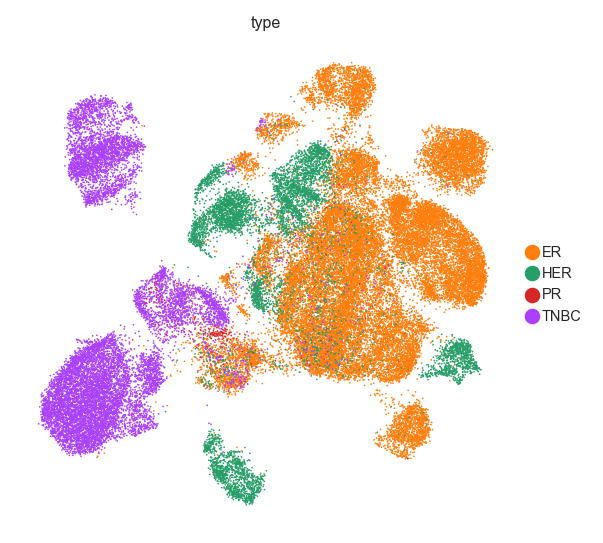

In [103]:
# visualise the new embedding space
sc.pl.embedding(adata, basis="X_umap_aucell", color="type")

Identified 10 modules at distance threshold 0.9


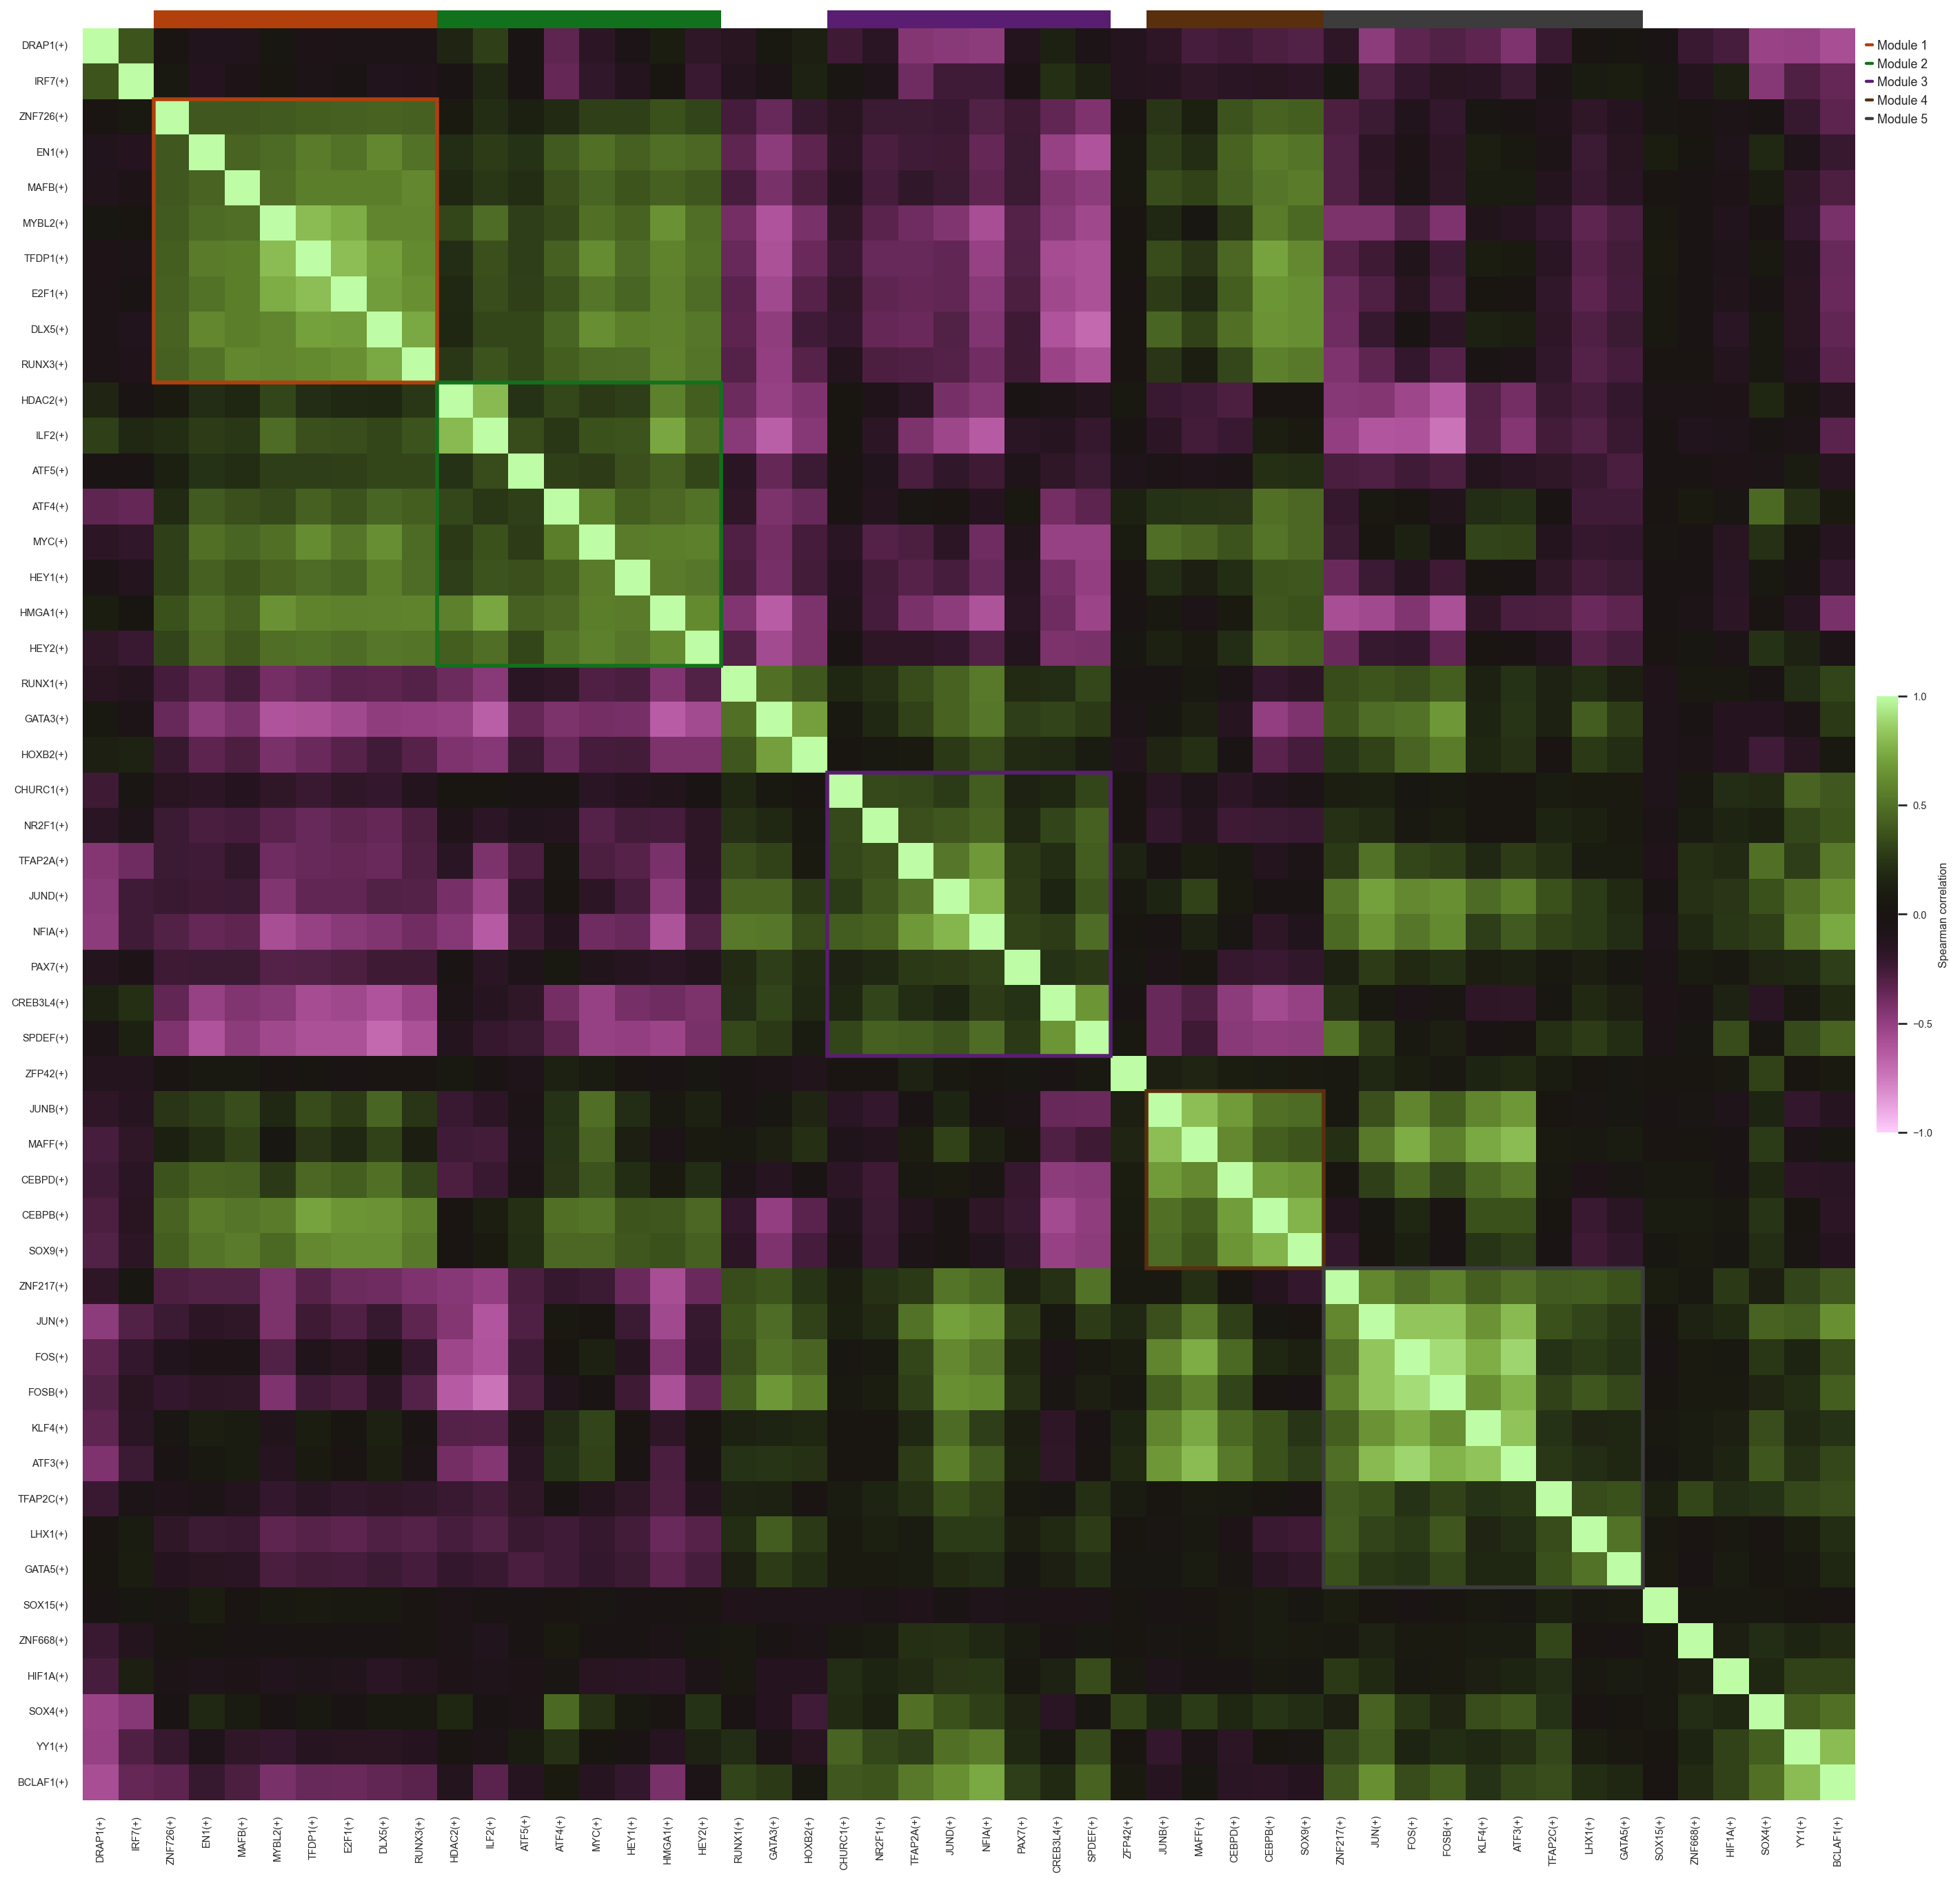

In [104]:
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as spc
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Prepare AUC and select top regulons:
auc_mtx["type"] = adata.obs["type"]
mean_auc_by_type = auc_mtx.groupby("type").median()
del auc_mtx["type"]

top_n = 50
top_tfs = (
    mean_auc_by_type.max(axis=0).sort_values(ascending=False).head(top_n).index.tolist()
)
auc_mtx = auc_mtx[top_tfs]

# Correlation matrix:
correlation_matrix = auc_mtx.corr(method="spearman")
correlation_matrix = pd.DataFrame(
    np.nan_to_num(correlation_matrix), index=auc_mtx.columns, columns=auc_mtx.columns
)

# Hierarchical clustering-based module detection:
dist_matrix = 1 - correlation_matrix
pdist = spc.distance.squareform(dist_matrix.values, checks=False)
linkage = spc.linkage(pdist, method="complete")

# Infer modules by distance threshold:
threshold = 0.9
labels = spc.fcluster(linkage, threshold, criterion="distance")
modules = pd.Series(labels, index=correlation_matrix.columns, name="Module")
n_modules = modules.nunique()
print(f"Identified {n_modules} modules at distance threshold {threshold}")

# Reorder regulons by dendrogram:
dendro = spc.dendrogram(linkage, no_plot=True)
ordered_genes = [correlation_matrix.columns[i] for i in dendro["leaves"]]
correlation_matrix = correlation_matrix.loc[ordered_genes, ordered_genes]
ordered_modules = modules.loc[ordered_genes]

# Identify contiguous cluster spans:
spans = []
start = 0
current_label = ordered_modules.iloc[0]
for i, lbl in enumerate(ordered_modules):
    if lbl != current_label:
        spans.append((current_label, start, i))
        start = i
        current_label = lbl
spans.append((current_label, start, len(ordered_modules)))

# Colour maps:
palette = sns.color_palette("dark", n_modules)
module_color_map = dict(zip(sorted(ordered_modules.unique()), palette))

# Determine which modules will actually be plotted:
plotted_spans = []
plotted_labels = []
for cluster_label, start_idx, end_idx in spans:
    if end_idx - start_idx < 4:  # skip modules with <4 genes
        continue
    submatrix = correlation_matrix.iloc[start_idx:end_idx, start_idx:end_idx].copy()
    np.fill_diagonal(submatrix.values, np.nan)
    median_corr = np.nanmedian(submatrix.values)
    if np.isnan(median_corr) or abs(median_corr) < 0.3:
        continue
    plotted_spans.append((cluster_label, start_idx, end_idx))
    plotted_labels.append(cluster_label)

# Rename plotted modules sequentially:
label_map = {old: new + 1 for new, old in enumerate(sorted(set(plotted_labels)))}
module_color_map = {label_map[k]: module_color_map[k] for k in plotted_labels}
plotted_spans = [(label_map[cl], s, e) for cl, s, e in plotted_spans]

# Plot heatmap:
plt.figure(figsize=(20, 20))
sns.set_theme(style="white", font_scale=0.6)
ax = sns.heatmap(
    correlation_matrix,
    cmap="vanimo",
    square=True,
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={
        "shrink": 0.2,
        "label": "Spearman correlation",
        "ticks": [-1, -0.5, 0, 0.5, 1],
        "pad": 0.01,
    },
    xticklabels=True,
    yticklabels=True,
)

# Draw module boundaries:
for cluster_label, start_idx, end_idx in plotted_spans:
    size = end_idx - start_idx
    color = module_color_map[cluster_label]
    ax.add_patch(
        Rectangle(
            (start_idx, start_idx),
            size,
            size,
            fill=False,
            edgecolor=color,
            linewidth=2.5,
            zorder=5,
        )
    )

# Top colour bar:
bar_ax = inset_axes(
    ax,
    width="100%",
    height="1%",
    loc="upper center",
    bbox_to_anchor=(0, 0.01, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
for cluster_label, start_idx, end_idx in plotted_spans:
    start_frac = start_idx / len(ordered_genes)
    width_frac = (end_idx - start_idx) / len(ordered_genes)
    color = module_color_map[cluster_label]
    bar_ax.add_patch(
        Rectangle(
            (start_frac, 0),
            width_frac,
            1,
            transform=bar_ax.transAxes,
            facecolor=color,
            edgecolor="none",
        )
    )
bar_ax.set_xticks([])
bar_ax.set_yticks([])
bar_ax.set_xlim(0, 1)
bar_ax.set_ylim(0, 1)
bar_ax.axis("off")

# Legend: only show plotted modules sequentially
legend_handles = [
    plt.Line2D([0], [0], color=module_color_map[m], lw=2, label=f"Module {m}")
    for m in sorted(module_color_map.keys())
]
ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1, 1),
    ncol=1,
    frameon=False,
    fontsize=8,
)

plt.tight_layout()
plt.savefig(f"figures/{sample}_correlation_heatmap_modules.pdf", bbox_inches="tight")
plt.show()

In [105]:
top_tfs = ordered_modules.index.tolist()
# average AUC per regulon
mean_auc_by_type_top_n = mean_auc_by_type[
    [c for c in mean_auc_by_type.columns if c in top_tfs]
]
mean_auc_by_type_top_n = mean_auc_by_type_top_n[top_tfs]
# write to file
outpath = os.path.join("results", f"{sample}_mean_auc_by_type_top_n.csv")
mean_auc_by_type_top_n.T.to_csv(outpath)

In [106]:
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

normalizing counts per cell


    finished (0:00:00)


In [107]:
# extract top regulons without (+)
tf_names = [gene.rstrip("(+)") for gene in top_tfs]
adata_top_tfs = adata[:, adata.var_names.isin(tf_names)]

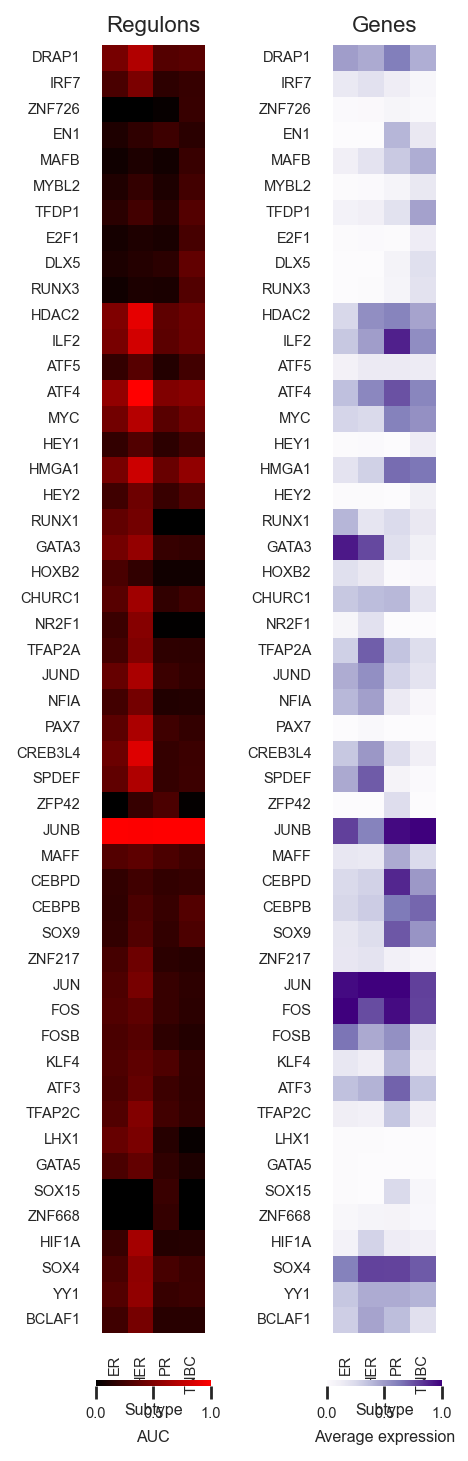

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np

from matplotlib.gridspec import GridSpec

# Ensure common rows (samples/cells):
mean_auc_by_type_top_n.columns = mean_auc_by_type_top_n.columns.str.replace(r"\(\+\)", "", regex=True)
common_rows = mean_auc_by_type_top_n.columns.intersection(adata_top_tfs.var_names)

data1 = mean_auc_by_type_top_n.T.loc[common_rows]

# rescale between 0 and 1 for better visualisation
data1 = (data1 - data1.min()) / (data1.max() - data1.min())

groupby = "type"
gene_list = tf_names
cmap = cmap_aucell

# Prepare matrixplot aggregated by group:
expr_df = pd.DataFrame(
    adata[:, gene_list].X.toarray() if hasattr(adata.X, "toarray") else adata[:, gene_list].X,
    index=adata.obs_names,
    columns=gene_list,
)

# scale expression data per gene for better visualisation
expr_df = (expr_df - expr_df.min()) / (expr_df.max() - expr_df.min())

# Aggregate by group
group_means = expr_df.groupby(adata.obs[groupby]).mean()
group_means = group_means.T  # genes x groups, vertical orientation

# scale between 0 and 1 for better visualisation per gene
group_means = (group_means - group_means.min()) / (group_means.max() - group_means.min())

# Figure size:
fig_height = max(data1.shape[1], len(gene_list)) * 0.2

gs = GridSpec(1, 2, width_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(3, fig_height))

# First heatmap:
ax0 = fig.add_subplot(gs[0, 0])
sns.heatmap(
    data1,
    ax=ax0,
    cmap=cmap_aucell,
    cbar=True,
    square=True,
    yticklabels=True,
    xticklabels=True,
    cbar_kws={
        "label": "AUC",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.03,
    },
    vmin=0,
    vmax=1,
)
ax0.set_title("Regulons", fontsize=10)
ax0.set_yticklabels(ax0.get_yticklabels(), rotation=0)
ax0.set_xlabel("Subtype")

# --- Second heatmap (matrixplot aggregated) ---
ax1 = fig.add_subplot(gs[0, 1])
sns.heatmap(
    group_means,
    ax=ax1,
    cmap="Purples",
    cbar=True,
    cbar_kws={
        "label": "Average expression",
        "shrink": 0.5,
        "orientation": "horizontal",
        "pad": 0.03,
    },
    square=True,
    yticklabels=True,
    xticklabels=True,
    vmin=0,
    vmax=1,
)
ax1.set_title("Genes", fontsize=10)
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)
ax1.set_xlabel("Subtype")

plt.subplots_adjust(left=0.05, right=0.95, wspace=0)
plt.tight_layout(pad=0)
plt.savefig(f"figures/{sample}_regulon_gene_expression_heatmap.pdf", bbox_inches="tight")
plt.show()

In [109]:
# load the motifs
df_motifs = load_motifs(f"results/{sample}_motifs.csv")
# derive regulons
regulons = derive_regulons(df_motifs)

with open(f"results/{sample}_oren_motifs.dat", "wb") as f:
    pickle.dump(regulons, f)

# rename regulons
auc_mtx.columns = auc_mtx.columns.str.replace("\(\+\)", "")
# add metadata to AnnData
add_scenic_metadata(adata, auc_mtx, regulons)

Create regulons from a dataframe of enriched features.
Additional columns saved: []


AnnData object with n_obs × n_vars = 52207 × 22803
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'type', 'patient', 'annotation', 'percent.mt', 'Phase', 'CC.Difference', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'integrated_snn_res.2', 'celltype', 'malignancy', 'cellclass', 'quiescence_score', 'cycling_state', 'QuiescenceType', 'disease', 'ident', 'oren_quiescence', 'cycling_state_oren', 'Regulon(JUNB(+))', 'Regulon(HMGA1(+))', 'Regulon(ATF4(+))', 'Regulon(MYC(+))', 'Regulon(HDAC2(+))', 'Regulon(ILF2(+))', 'Regulon(CREB3L4(+))', 'Regulon(DLX5(+))', 'Regulon(DRAP1(+))', 'Regulon(GATA3(+))', 'Regulon(KLF4(+))', 'Regulon(MAFF(+))', 'Regulon(ZFP42(+))', 'Regulon(TFDP1(+))', 'Regulon(CEBPB(+))', 'Regulon(RUNX3(+))', 'Regulon(SPDEF(+))', 'Regulon(HEY2(+))', 'Regulon(SOX4(+))', 'Regulon(PAX7(+))', 'Regulon(JUND(+))', 'Regulon(LHX1(+))', 'Regulon(SOX9(+))', 'Regulon(HIF1A(+))', 'Regulon(RUNX1(+))', 'Regulon(CHURC1(+))', 'Regulon(TFAP2C(+))', 'Regulon(E2F1(+))', 'Regulon(EN1(+))',

In [110]:
# calculate regulon specificity scores
rss_score = regulon_specificity_scores(auc_mtx, adata.obs.type)

def regulon_to_gene(reg_name):
    return reg_name.split("(")[0]

expressed_regulons = []
for reg in rss_score.columns:
    base_gene = regulon_to_gene(reg)
    if base_gene in adata.var_names:
        if (rss_score[reg] > 0.6).any() and (adata[:, base_gene].X > 0.1).sum() > 0:
            expressed_regulons.append(reg)

# Create a new list with converted gene names
regulon_names = [convert_gene_name(gene) for gene in expressed_regulons]

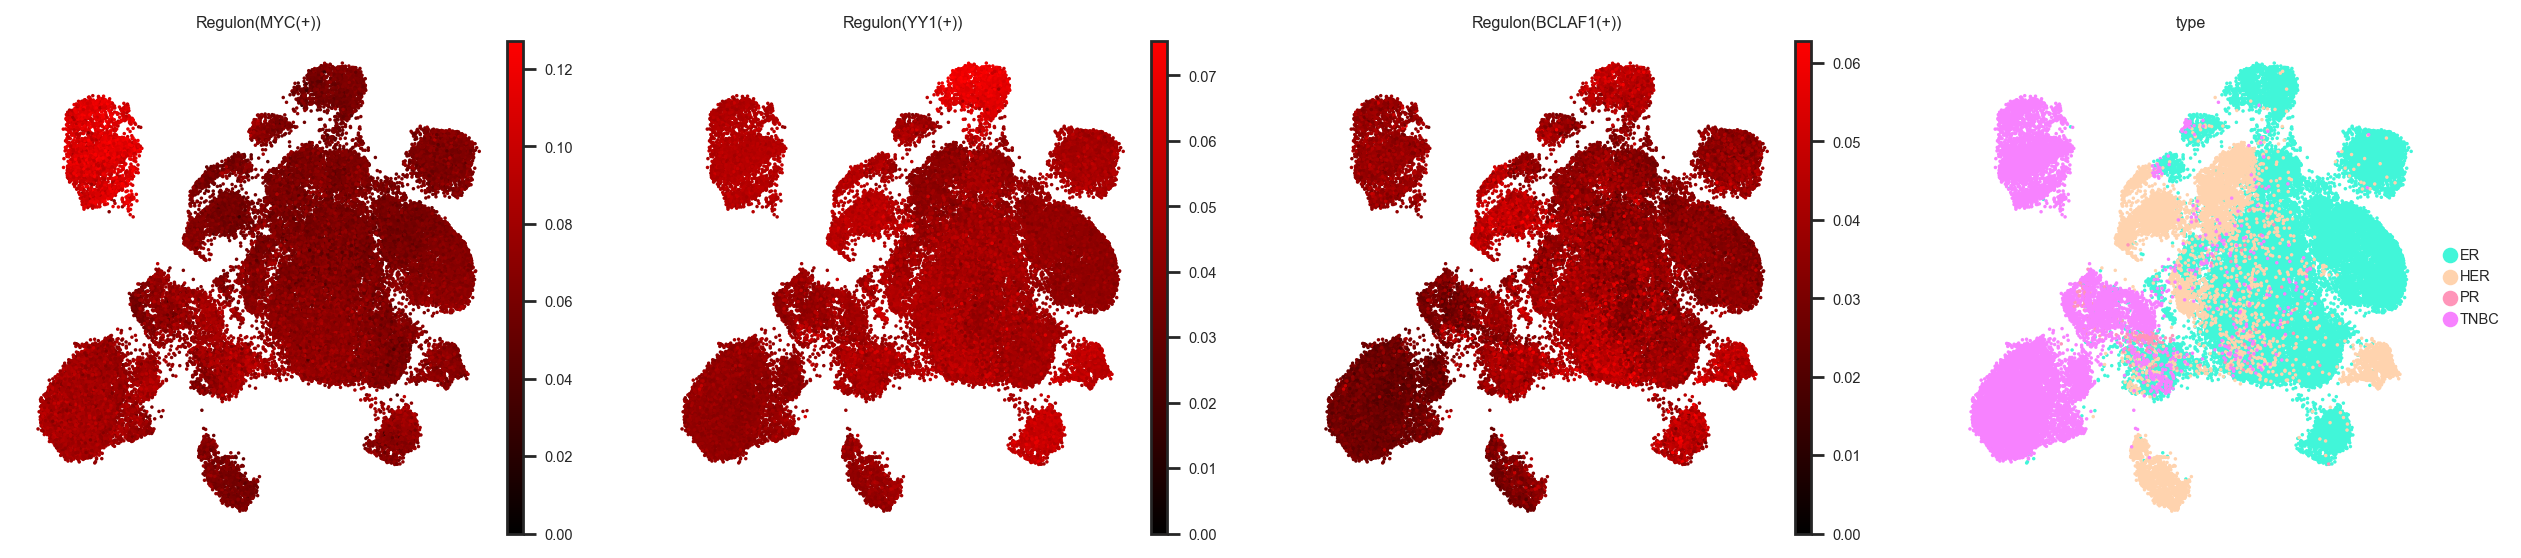

In [111]:
# plot them on the new embedding space
sc.pl.embedding(
    adata,
    basis="X_umap_aucell",
    color=["Regulon(MYC(+))", "Regulon(YY1(+))", "Regulon(BCLAF1(+))", "type"],
    palette=cmap_type,
    cmap=cmap_aucell,
    sort_order=False,
    vmax="p99.9",
    vmin=0,
    size=10,
    ncols=5,
    save=f"_{sample}_rss_regulon_activity.pdf",
)

In [112]:
rss_slow = regulon_specificity_scores(auc_mtx, adata.obs.type)
cats = ["ER", "PR", "HER", "TNBC"]

## Regulon specificity scores

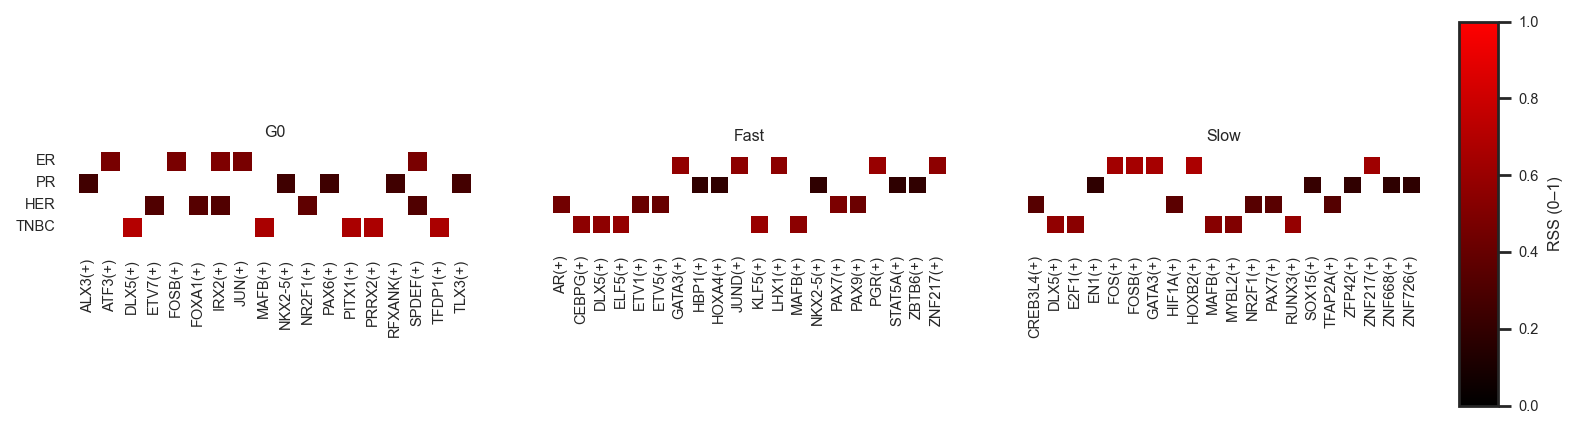

In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

cats = ["ER", "PR", "HER", "TNBC"]
states = ["G0", "Fast", "Slow"]

rss_all = pd.concat(
    {"G0": rss_g0, "Fast": rss_fast, "Slow": rss_slow},
    axis=0,
).rename_axis(index=["state", "cat"])

rows = []
for state in states:
    for cat in cats:
        s = rss_all.loc[(state, cat)]
        top = s.sort_values(ascending=False).head(5)
        rows.append(
            pd.DataFrame(
                {
                    "state": state,
                    "cat": cat,
                    "regulon": top.index,
                    "RSS": top.values,
                }
            )
        )

long_df = pd.concat(rows, ignore_index=True)

# hard scale 0–1
norm = Normalize(vmin=0.0, vmax=1.0)

# move colourbar to the right, outside the heat maps

fig, axes = plt.subplots(1, len(states), figsize=(12, 4), sharey=True)

for ax, state in zip(axes, states):
    data = long_df[long_df["state"] == state]
    mat = data.pivot(index="cat", columns="regulon", values="RSS").loc[cats]

    sns.heatmap(
        mat,
        ax=ax,
        cmap=cmap_aucell,
        norm=norm,
        cbar=False,
        linewidths=0.5,
        square=True,
    )
    ax.set_title(state)
    ax.set_xlabel("")
    ax.set_ylabel("")

# reserve space on the right
fig.subplots_adjust(right=0.88)

# explicit colourbar axis
cax = fig.add_axes([0.90, 0.20, 0.02, 0.60])

sm = plt.cm.ScalarMappable(cmap=cmap_aucell, norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="RSS (0–1)")
plt.savefig("figures/regulon_specificity_scores_top5_per_state_and_cat.pdf", bbox_inches="tight")
plt.show()